In [14]:
import cv2
from cv2 import aruco
import numpy as np
import msgpack as mp
import msgpack_numpy as mpn
import os
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed

In [15]:
patternSize = (8, 12)
squareSize = 30
imgSize = (1280, 800)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

def construct3DPoints(patternSize, squareSize):
    X = np.zeros((patternSize[0] * patternSize[1], 3), np.float32)
    X[:, :2] = np.mgrid[0 : patternSize[0], 0 : patternSize[1]].T.reshape(-1, 2)
    X = X * squareSize
    return X


boardPoints = construct3DPoints(patternSize, squareSize)

In [27]:
_pth = os.path.dirname(os.getcwd())
_parent_folder = "data"
_calib_folder_name = "dual_cam_calibration_checker_sz_30mm"

_webcam_calib_folder = os.path.join(
    _pth,'..', _parent_folder, "calibration",'dual_160', _calib_folder_name
)

_camera = 'cam1_ov9281'
_webcam_calib_video = os.path.join(_webcam_calib_folder, f"{_camera}.msgpack")

In [17]:
_video_pth = _webcam_calib_video
_video_file = open(_video_pth, "rb")
_video_data = mp.Unpacker(_video_file, object_hook=mpn.decode)
_video_length = 0

for _frame in _video_data:
    _video_length += 1

_video_file.close()

print('video length, ', _video_length)

video length,  4271


In [18]:
_frame.shape

(800, 1280)

In [19]:
_video_pth = _webcam_calib_video
_video_file = open(_video_pth, "rb")
_video_data = mp.Unpacker(_video_file, object_hook=mpn.decode)

chessb_corners = []
counter = 0

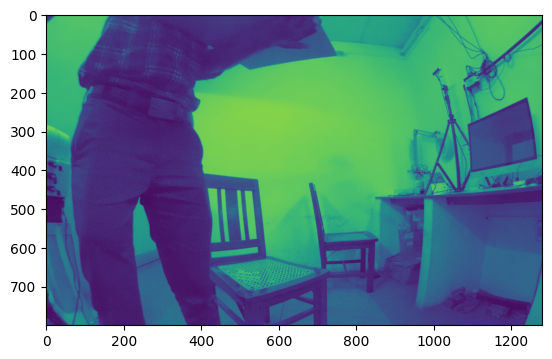

In [20]:
plt.imshow(_frame)

In [21]:
# for idx, frame in enumerate(tqdm(_video_data)):
def detectCorners(data):
    # _frame = cv2.rotate(_frame.copy(), cv2.ROTATE_180)
    frame_id, _frame = data
    if len(_frame.shape) == 3:
        _frame = cv2.cvtColor(_frame, cv2.COLOR_RGB2GRAY)
    ret, corners = cv2.findChessboardCorners(_frame, patternSize)
    if ret:
        corners = cv2.cornerSubPix(
            _frame,
            corners,
            (5, 5),
            (-1, -1),
            criteria=(cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001),
        )
    else:
        return None, frame_id
    return corners, frame_id
# Parallel execution with joblib
chessb_corners = []
results = Parallel(n_jobs=20, verbose=0)(
    delayed(detectCorners)(frame) for frame in tqdm(enumerate(_video_data))
)


0it [00:00, ?it/s]

# Clean up the inhomogeneous  part

In [22]:
# Collect results
chessb_corners = []
for result, frame_id in results:
    if result is not None and len(result) == 96:
        chessb_corners.append([result, frame_id])

In [23]:
len(chessb_corners)

4053

In [24]:
STOP_HERE

NameError: name 'STOP_HERE' is not defined

In [28]:
# Get the directory of the video file
video_dir = os.path.dirname(_video_pth)
corners_file = os.path.join(video_dir, f"chessb_corners_{_camera}.msgpack")

with open(corners_file, "wb") as f:
    _packed_file = mp.packb(chessb_corners, default=mpn.encode)
    f.write(_packed_file)

# del(chessb_corners)

In [ ]:
STOP_HERE

NameError: name 'STOP_HERE' is not defined

# Creating combinations

In [1]:
import cv2
from cv2 import aruco
import numpy as np
import msgpack as mp
import msgpack_numpy as mpn
import os
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed
np.random.seed(9)

In [18]:
_pth = os.path.dirname(os.getcwd())
_parent_folder = "data"
_calib_folder_name = "dual_cam_calibration_checker_sz_30mm"

_webcam_calib_folder = os.path.join(
    _pth,'..', _parent_folder, "calibration",'dual_160', _calib_folder_name
)
_webcam_calib_video = os.path.join(_webcam_calib_folder, "cam1_ov9281.msgpack")
_webcam_calib_folder = os.path.join(_webcam_calib_folder)
_webcam_corners_pth = os.path.join(_webcam_calib_folder, "chessb_corners_cam0_imx219.msgpack")

In [28]:
# load data

_corners_file = open(_webcam_corners_pth, "rb")
chessb_corners = list(mp.Unpacker(_corners_file, object_hook=mpn.decode))[0]

chessboard_data = {'cb_corners':[], 'frame_id':[]}
for c, id in chessb_corners:
    chessboard_data['cb_corners'].append(c)
    chessboard_data['frame_id'].append(id)
chessb_corners = chessboard_data['cb_corners']
chessb_corners = np.array(chessb_corners)

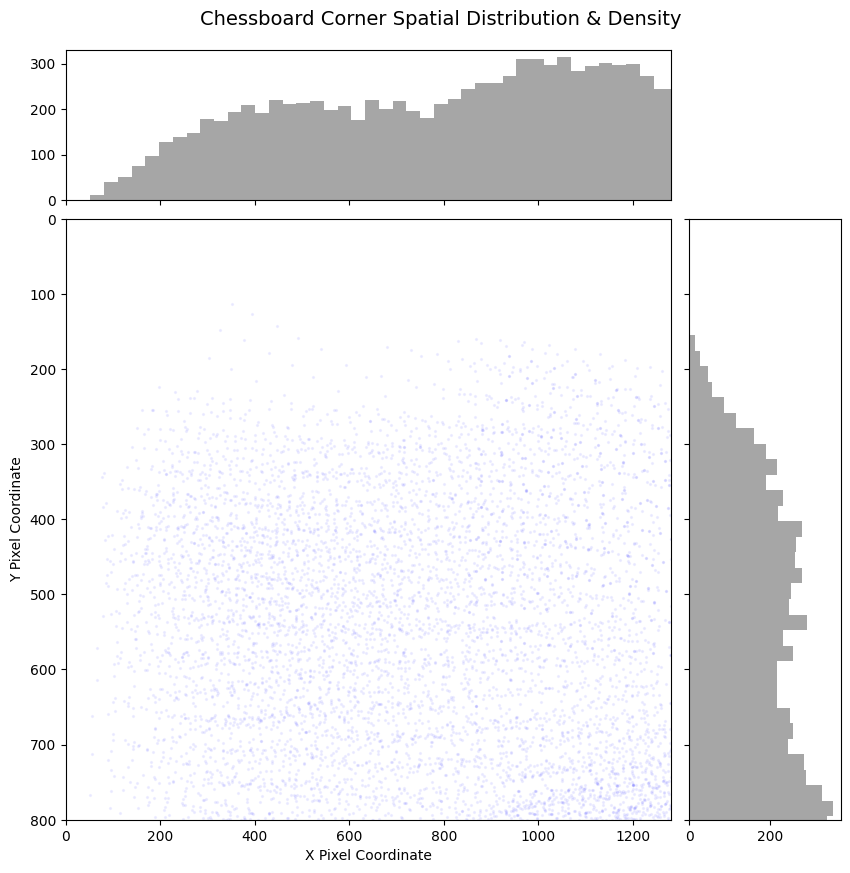

In [30]:
rnd = np.random.choice(len(chessb_corners), 100)
chessb_c = chessb_corners[rnd]

# 1. Reshape the data (same as before)
# Assuming 'corners' is your array of shape (6785, 24, 1, 2)
flat_corners = chessb_c.reshape(-1, 2)
x_coords = flat_corners[:, 0]
y_coords = flat_corners[:, 1]

# 2. Set up the Figure and Grid Layout
fig = plt.figure(figsize=(10, 10))

# Create a 2x2 grid. 
# The scatter plot takes up a 4x4 ratio, while the histograms take up a 1x4 and 4x1 ratio.
gs = fig.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 4),
                      wspace=0.05, hspace=0.05)

# 3. Create the Axes
ax_main = fig.add_subplot(gs[1, 0])
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_main)

# 4. Plot the Main Scatter Plot
ax_main.scatter(x_coords, y_coords, alpha=0.05, s=2, color='blue')
ax_main.set_xlabel('X Pixel Coordinate')
ax_main.set_ylabel('Y Pixel Coordinate')

# Invert the Y-axis so it matches image coordinates (origin top-left)
ax_main.invert_yaxis()

# 5. Plot the X-Axis Histogram (Top)
# We use 50 bins, but you can adjust this depending on your image resolution
ax_histx.hist(x_coords, bins=50, color='gray', alpha=0.7)
ax_histx.tick_params(axis="x", labelbottom=False) # Hide X labels to prevent overlap

# 6. Plot the Y-Axis Histogram (Right)
# Crucial: set orientation='horizontal' so the bars align with the scatter plot's Y-axis
ax_histy.hist(y_coords, bins=50, orientation='horizontal', color='gray', alpha=0.7)
ax_histy.tick_params(axis="y", labelleft=False) # Hide Y labels to prevent overlap

# Optional: Set limits if you know your camera resolution (e.g., 1920x1080)
ax_main.set_xlim(0, 1280)
ax_main.set_ylim(800, 0) # Remember this is flipped!

plt.suptitle('Chessboard Corner Spatial Distribution & Density', fontsize=14, y=0.92)
plt.show()

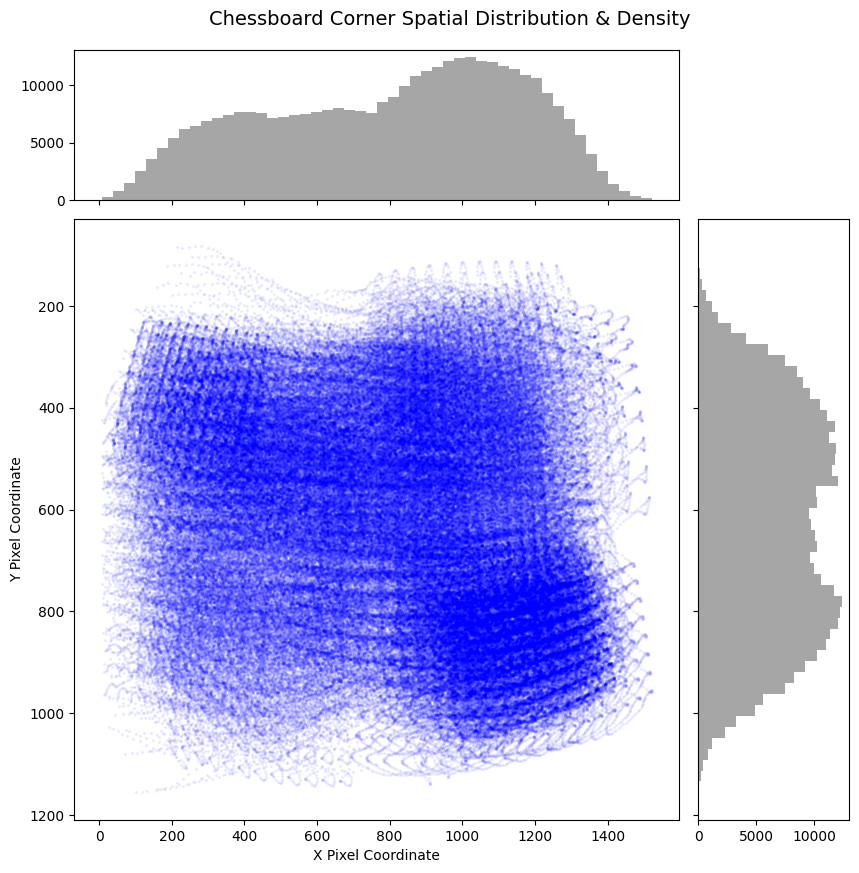

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Reshape the data (same as before)
# Assuming 'corners' is your array of shape (6785, 24, 1, 2)
flat_corners = chessb_corners.reshape(-1, 2)
x_coords = flat_corners[:, 0]
y_coords = flat_corners[:, 1]

# 2. Set up the Figure and Grid Layout
fig = plt.figure(figsize=(10, 10))

# Create a 2x2 grid. 
# The scatter plot takes up a 4x4 ratio, while the histograms take up a 1x4 and 4x1 ratio.
gs = fig.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 4),
                      wspace=0.05, hspace=0.05)


# 3. Create the Axes
ax_main = fig.add_subplot(gs[1, 0])
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_main)

# 4. Plot the Main Scatter Plot
ax_main.scatter(x_coords, y_coords, alpha=0.05, s=2, color='blue')
ax_main.set_xlabel('X Pixel Coordinate')
ax_main.set_ylabel('Y Pixel Coordinate')

# Invert the Y-axis so it matches image coordinates (origin top-left)
ax_main.invert_yaxis()

# 5. Plot the X-Axis Histogram (Top)
# We use 50 bins, but you can adjust this depending on your image resolution
ax_histx.hist(x_coords, bins=50, color='gray', alpha=0.7)
ax_histx.tick_params(axis="x", labelbottom=False) # Hide X labels to prevent overlap

# 6. Plot the Y-Axis Histogram (Right)
# Crucial: set orientation='horizontal' so the bars align with the scatter plot's Y-axis
ax_histy.hist(y_coords, bins=50, orientation='horizontal', color='gray', alpha=0.7)
ax_histy.tick_params(axis="y", labelleft=False) # Hide Y labels to prevent overlap

# Optional: Set limits if you know your camera resolution (e.g., 1920x1080)
# ax_main.set_xlim(0, 1280)
# ax_main.set_ylim(800, 0) # Remember this is flipped!

plt.suptitle('Chessboard Corner Spatial Distribution & Density', fontsize=14, y=0.92)
plt.show()

In [6]:
patternSize = (8, 12)
squareSize = 30
imgSize = (1280, 800)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

def construct3DPoints(patternSize, squareSize):
    X = np.zeros((patternSize[0] * patternSize[1], 3), np.float32)
    X[:, :2] = np.mgrid[0 : patternSize[0], 0 : patternSize[1]].T.reshape(-1, 2)
    X = X * squareSize
    return X


boardPoints = construct3DPoints(patternSize, squareSize)

In [7]:
permute_value = 20

In [10]:

useFisheye = True
def calibrate_single_iteration(_):
    rnd = np.random.choice(len(chessb_corners), 90)
    chessb_c = chessb_corners[rnd]
    worldPoints = []
    imagePoints = []
    useFisheye = True

    for _f in chessb_c:
        imagePoints.append(_f)
        worldPoints.append(boardPoints)

    if useFisheye:
        flagsCalib = (
            cv2.fisheye.CALIB_RECOMPUTE_EXTRINSIC  # Vital for convergence
            + cv2.fisheye.CALIB_FIX_SKEW           # Sensors don't have skew
            + cv2.fisheye.CALIB_CHECK_COND         # Safety check
            # + cv2.fisheye.CALIB_FIX_K3             # See note below
            # + cv2.fisheye.CALIB_FIX_K4             # See note below
        )
        # 2. Set Flags for 160 deg / 15% distortion
        # flagsCalib = (
        #     cv2.fisheye.CALIB_RECOMPUTE_EXTRINSIC
        #     # | cv2.fisheye.CALIB_FIX_SKEW 
        #     # | cv2.fisheye.CALIB_CHECK_COND
        #     # | cv2.fisheye.CALIB_FIX_PRINCIPAL_POINT 
        #     # Start by fixing higher order coeffs for low-distortion fisheyes
        #     # to prevent "wavy" edges. If RMS is bad, comment these out.
        #     # | cv2.fisheye.CALIB_FIX_K3 
        #     # | cv2.fisheye.CALIB_FIX_K4
        #     # | cv2.fisheye.CALIB_ZERO_DISPARITY
        # )

        # flagsCalib = (cv2.fisheye.CALIB_USE_INTRINSIC_GUESS
        # # | cv2.fisheye.CALIB_FIX_SKEW 
        # | cv2.fisheye.CALIB_RECOMPUTE_EXTRINSIC
        # | cv2.fisheye.CALIB_CHECK_COND
        # # | cv2.fisheye.CALIB_FIX_K4
        # )

        # f ~ 540 based on r/theta calculation for 1/4" sensor
        K_init = np.array([[540.0, 0.0, 640.0],
                        [0.0, 540.0, 400.0],
                        [0.0, 0.0, 1.0]])
        D_init = np.zeros((4, 1))



        calibrateCriteria = (
            cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
            500,
            # 1e-12,
            1e-9,
        )
        ret, cameraMatrix, k, R, t = cv2.fisheye.calibrate(
            np.expand_dims(np.asarray(worldPoints), -2),
            imagePoints,
            imgSize,
            None, # if we are not using the internsic guess
            None,
            # K_init,
            # D_init,
            flags=flagsCalib,
            criteria=calibrateCriteria,
        )
    else:
        flagsCalib = cv2.CALIB_RATIONAL_MODEL
        ret, cameraMatrix, k, R, t = cv2.calibrateCamera(
            worldPoints, imagePoints, imgSize, None, None, flags=flagsCalib
        )

    # print(worldPoints)
    return {"ReError": ret, "mat": cameraMatrix, "dist": k, "rvec": R, "tvec": t, 'rnd':rnd}


# Parallel execution with joblib
my_dict = {"ReError": [], "mat": [], "dist": [], "rvec": [], "tvec": [], 'rnd_value':[]}


results = Parallel(n_jobs=20, verbose=0)(
    delayed(calibrate_single_iteration)(_) for _ in tqdm(range(permute_value))
)
# Collect results
for result in results:
    my_dict["ReError"].append(result["ReError"])
    my_dict["mat"].append(result["mat"])
    my_dict["dist"].append(result["dist"])
    my_dict["rvec"].append(result["rvec"])
    my_dict["tvec"].append(result["tvec"])
    my_dict['rnd_value'].append(result['rnd'])


# calibrate_single_iteration(10)

  0%|          | 0/20 [00:00<?, ?it/s]

In [11]:
# video_dir = os.path.dirname(_video_pth)
if useFisheye:
    calibration_file = os.path.join(_webcam_calib_folder, f"calibration_data_{permute_value}.msgpack")
else:
    calibration_file = os.path.join(_webcam_calib_folder, f"standard_calibration_data_{permute_value}.msgpack")

with open(calibration_file, "wb") as f:
    _packed_file = mp.packb(my_dict, default=mpn.encode)
    f.write(_packed_file)

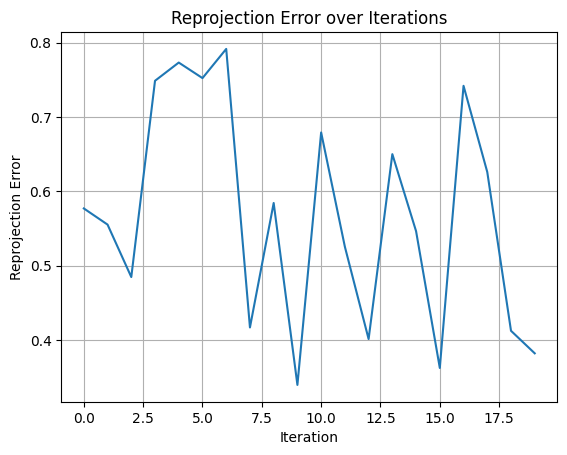

In [12]:
plt.plot(my_dict['ReError'])
plt.xlabel('Iteration')
plt.ylabel('Reprojection Error')
plt.title('Reprojection Error over Iterations')
plt.grid()

In [13]:
min_rerr_idx = np.argmin(my_dict['ReError'])
print('Minimum Reprojection Error:', my_dict['ReError'][min_rerr_idx], ' at index ', min_rerr_idx)

Minimum Reprojection Error: 0.33977219530646957  at index  9


In [14]:
rerr = my_dict['ReError'][min_rerr_idx]
camera_mat = my_dict['mat'][min_rerr_idx]
camera_dist = my_dict['dist'][min_rerr_idx]

In [15]:
print(rerr, camera_mat, camera_dist)

0.33977219530646957 [[596.2426394    0.         661.03018166]
 [  0.         597.52793108 368.11420796]
 [  0.           0.           1.        ]] [[-0.03673179]
 [ 0.00275778]
 [-0.00788903]
 [ 0.00243829]]


Translation Vector Standard Deviation: [332.58538934 118.78930457 104.11300245]


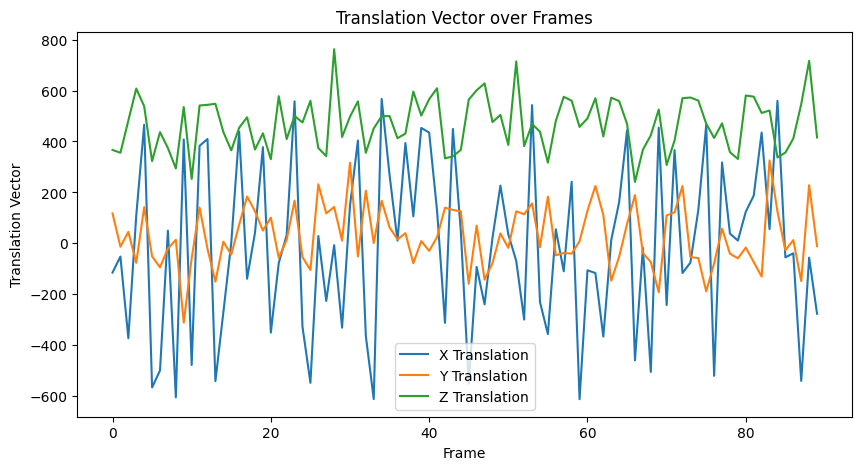

In [16]:
# plot the translation vector
tvec = my_dict['tvec'][0]
tvec = np.array(tvec).T[0]
plt.figure(figsize=(10, 5))
plt.plot(tvec[0], label='X Translation')
plt.plot(tvec[1], label='Y Translation')
plt.plot(tvec[2], label='Z Translation')
plt.xlabel('Frame')
plt.ylabel('Translation Vector')
plt.title('Translation Vector over Frames')
plt.legend()

# standard deviation of the translation vector
tvec_std = np.std(tvec, axis=1)
print('Translation Vector Standard Deviation:', tvec_std)

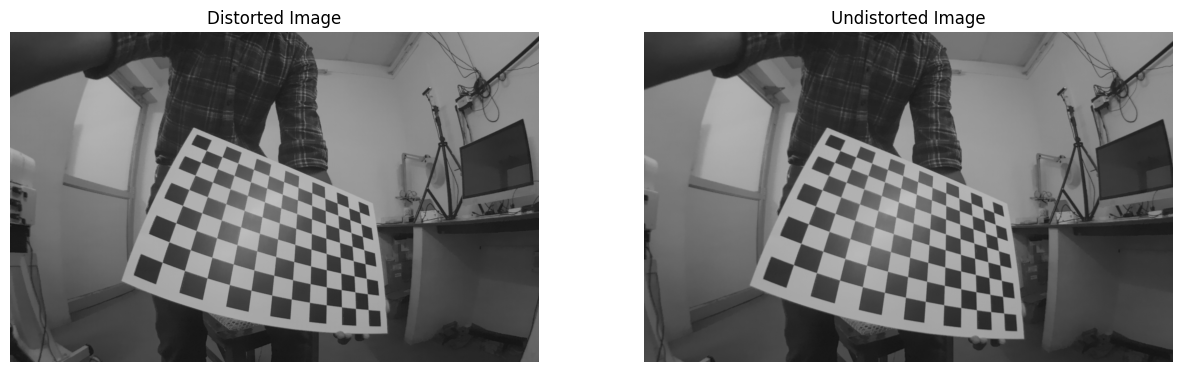

In [17]:
# show distorted and undistorted images
_video_pth = _webcam_calib_video
_video_file = open(_video_pth, "rb")
_video_data = mp.Unpacker(_video_file, object_hook=mpn.decode)
for idx, frame in enumerate(_video_data):
    # frame = cv2.flip(frame, 0)
    # frame = cv2.rotate(frame, cv2.ROTATE_180)
    frame_undistorted = cv2.undistort(frame, camera_mat, camera_dist)
    # create a subplot with 2 images and break at first image and plot chessboard corners
    
    if idx == 0:
        plt.figure(figsize=(15, 8))
        plt.subplot(1, 2, 1)
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.title('Distorted Image')
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(cv2.cvtColor(frame_undistorted, cv2.COLOR_BGR2RGB))
        plt.title('Undistorted Image')
        plt.axis('off')
        plt.show()
        break

In [ ]:
STOP_HERE

NameError: name 'STOP_HERE' is not defined

# Analysis by using a second video

In [ ]:
import sys
import cv2
from cv2 import aruco
import numpy as np
import msgpack as mp
import msgpack_numpy as mpn
import os
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed
import polars as pl
from datetime import datetime
    
sys.path.insert(1, os.path.dirname(os.getcwd()))
from pd_support import *
from scipy.spatial.transform import Rotation as R
import polars as pl
import os
from scipy.interpolate import interp1d
from joblib import Parallel, delayed

In [86]:
_pth = os.path.dirname(os.getcwd())
_parent_folder = "data"
_fov = "160_fov"
_calib_fov = 'dual_160'
permute_value = 20

useFisheye = True

_calib_folder_name = "dual_cam_calibration_checker_sz_30mm"
_recording_folder_name = "3marker_linear_2d_160fov_t1"
# _recording_folder_name = "3marker_120fov_linear_ext_t0"

_webcam_calib_folder = os.path.join(
    _pth,'..', _parent_folder, "calibration",_calib_fov, _calib_folder_name
)

_reference_recording_folder = os.path.join(
    _pth, '..', _parent_folder, "recordings",_fov,'3marker_complete_data', _recording_folder_name
)
_reference_file = os.path.join(_reference_recording_folder, "webcam_color.msgpack")

_timestamp_file = os.path.join(_reference_recording_folder, "webcam_timestamp.msgpack")
with open(_timestamp_file, "rb") as f:
    _metadata = list(mp.Unpacker(f, object_hook=mpn.decode))
    _timestamp = np.array(_metadata)[:,1]
    _sync_pulse = np.array(_metadata)[:,0]

### load calibration combinations

In [87]:
if useFisheye:
    _calibration_data = os.path.join(_webcam_calib_folder, f'calibration_data_{permute_value}.msgpack')
else:
    _calibration_data = os.path.join(_webcam_calib_folder, f'standard_calibration_data_{permute_value}.msgpack')

with open(_calibration_data, 'rb') as f:
    my_dict = list(msgpack.Unpacker(f, object_hook=mpn.decode))
my_dict = my_dict[0]

In [88]:
_ref_video_length = 0

for _ in mp.Unpacker(open(_reference_file, "rb"), object_hook=mpn.decode):
    _ref_video_length += 1

print('video length, ', _ref_video_length)

video length,  4238


In [89]:
ARUCO_PARAMETERS = aruco.DetectorParameters()
ARUCO_DICT = aruco.getPredefinedDictionary(aruco.DICT_APRILTAG_36h11)
detector = aruco.ArucoDetector(ARUCO_DICT, ARUCO_PARAMETERS)
markerLength = 0.048
markerSeperation = 0.01

board = aruco.GridBoard(
    size=[1, 1],
    markerLength=markerLength,
    markerSeparation=markerSeperation,
    dictionary=ARUCO_DICT,
)

def estimate_pose_single_markers(
    corners, marker_size, camera_matrix, distortion_coefficients = np.zeros((5, 1))
):
    marker_points = np.array(
        [
            [-marker_size / 2, marker_size / 2, 0],
            [marker_size / 2, marker_size / 2, 0],
            [marker_size / 2, -marker_size / 2, 0],
            [-marker_size / 2, -marker_size / 2, 0],
        ],
        dtype=np.float32,
    )
    rvecs, tvecs = [], []
    for corner in corners:
        _, r, t = cv2.solvePnP(
            marker_points,
            corner,
            camera_matrix,
            distortion_coefficients,
            flags=cv2.SOLVEPNP_ITERATIVE,
        )
        if r is not None and t is not None:
            rvecs.append(r.reshape(1, 3).tolist())
            tvecs.append(t.reshape(1, 3).tolist())
        else:
            rvecs.append(np.array([[np.nan, np.nan, np.nan]]).tolist())
            tvecs.append(np.array([[np.nan, np.nan, np.nan]]).tolist())
    return np.array(rvecs, dtype=np.float32), np.array(tvecs, dtype=np.float32)

## load clalibration data

In [90]:
_calib_data = list(mp.Unpacker(open(_calibration_data, "rb"), object_hook=mpn.decode))

In [91]:
len(_calib_data[0]['ReError'])

20

In [92]:
# selecting random 50 frames
np.random.seed(9)
_random_reference_frames_idx = np.random.choice(_ref_video_length, 300)

_ref_data = mp.Unpacker(open(_reference_file, "rb"), object_hook=mpn.decode)

# _ref_frames = []

ar_total_results = {'calib_idx':[], 'ar_data':[]}
ar_results = {'corners': [], 'ids': [], 'rejected': []}
vector_std = {'v1std':[], 'v2std':[], 'v3std':[], 'sum':[], 
              'r1std':[], 'r2std':[], 'r3std':[], 'r_sum':[]}

for idx, _frame in tqdm(enumerate(_ref_data)):
    # if idx in _random_reference_frames_idx:

        # _frame = cv2.rotate(_frame, cv2.ROTATE_180)
    # _frame = cv2.flip(_frame, 1)
    res = detector.detectMarkers(_frame,)
    
    res = detector.refineDetectedMarkers(_frame, board, res[0], res[1], res[2])
    ar_results['corners'].append(res[0])
    ar_results['ids'].append(res[1])
    ar_results['rejected'].append(res[2])

0it [00:00, ?it/s]

## path definition

In [93]:
_timestamp

array(['2026-02-12 17:29:57.905428', '2026-02-12 17:29:57.911882',
       '2026-02-12 17:29:57.929378', ..., '2026-02-12 17:30:40.275345',
       '2026-02-12 17:30:40.288105', '2026-02-12 17:30:40.295118'],
      shape=(4238,), dtype='<U26')

In [94]:
ar_df = {"time": _timestamp, "sync": _sync_pulse}
ar_df = pl.from_dict(ar_df)
if type(ar_df["time"][0]) is not datetime:
    ar_df = ar_df.with_columns(pl.col("time").str.to_datetime())

In [95]:
mocap_df, st_time = read_rigid_body_csv(
    os.path.join(_reference_recording_folder, f"{_recording_folder_name}.csv")
)
mocap_df = add_datetime_col(mocap_df, st_time, "seconds")
mocap_df = pl.from_pandas(mocap_df)

e:\CMC\pyprojects\programs_rpi\NOARK_backbone\notebooks\pd_support.py:326: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  _rb_df = _rb_df.apply(pd.to_numeric, errors="ignore")


In [96]:
# from notebooks.pd_support import get_rb_marker_name
tr = get_rb_marker_name(2)
tl = get_rb_marker_name(6)
br = get_rb_marker_name(4)
bl = get_rb_marker_name(8)

# tr = get_rb_marker_name(8)
# tl = get_rb_marker_name(6)
# br = get_rb_marker_name(2)
# bl = get_rb_marker_name(5)


# tr = get_rb_marker_name(4)
# tl = get_rb_marker_name(2)
# br = get_rb_marker_name(3)
# bl = get_rb_marker_name(1)

to = get_rb_marker_name(1)

In [97]:
ar_df['sync'][0]

'0'

In [98]:
ar_df = ar_df.with_columns(
    pl.col("sync").cast(pl.Int8).cast(pl.Boolean)
)

In [99]:
start_pulse = ar_df["sync"].arg_true().head(1).item()
offset = (~ar_df["sync"].slice(start_pulse)).arg_true().head(1).item()

end_pulse = start_pulse + offset

print(f"Start pulse: {start_pulse}, End pulse: {end_pulse}")
ar_df = ar_df[start_pulse:end_pulse]
ar_corners = ar_results['corners'][start_pulse:end_pulse]
ids = ar_results['ids'][start_pulse:end_pulse]

_time_diff = mocap_df["time"][0] - ar_df["time"][0]

ar_df = ar_df.with_columns([(pl.col("time") + _time_diff).alias("time")])

Start pulse: 147, End pulse: 4165


In [100]:
mocap_df["time"][0]

datetime.datetime(2026, 2, 12, 17, 29, 59, 416000)

In [101]:
ar_df["time"][0]

datetime.datetime(2026, 2, 12, 17, 29, 59, 416000)

In [102]:
_time_diff

datetime.timedelta(microseconds=44776)

In [103]:
mocap_mean = {"x": [], "y": [], "z": []}
mocap_mean["x"] = mocap_df[[tr["x"], tl["x"], br["x"], bl["x"]]].to_numpy().mean(axis=1)
mocap_mean["y"] = mocap_df[[tr["y"], tl["y"], br["y"], bl["y"]]].to_numpy().mean(axis=1)
mocap_mean["z"] = mocap_df[[tr["z"], tl["z"], br["z"], bl["z"]]].to_numpy().mean(axis=1)

mocap_qt_0 = mocap_df[["rb_ang_x", "rb_ang_y", "rb_ang_z", "rb_ang_w"]][0].to_numpy()

mocap_rotation = R.from_quat(mocap_qt_0).as_matrix()

mocap_mean = pl.from_dict(mocap_mean)

mt_dict = {"x": [], "y": [], "z": []}
rmat_m = mocap_rotation[0]

for i in range(len(mocap_df["time"])):
    tvec_ar = rmat_m.T @ (
        mocap_mean[["x", "y", "z"]][i].to_numpy().reshape(3, 1)
        - mocap_mean[["x", "y", "z"]][0].to_numpy().reshape(3, 1)
    )
    tvec_ar = tvec_ar.T[0]
    mt_dict["x"].append(tvec_ar[0])
    mt_dict["y"].append(tvec_ar[1])
    mt_dict["z"].append(tvec_ar[2])

mt_dict["time"] = mocap_df["time"]

In [115]:
to_marker = mocap_df[[to['x'], to['y'], to['z']]].to_numpy()[0]
_offset_tvvv = rmat_m.T @ (mocap_mean[["x", "y", "z"]].to_numpy()[0].reshape(3, 1) - to_marker.reshape(3,1))

In [111]:
to_marker.reshape(3,1)

array([[-0.308709],
       [ 0.626666],
       [-0.059151]])

In [110]:
mocap_mean[["x", "y", "z"]].to_numpy()[0].reshape(3, 1)

array([[-0.304107],
       [ 0.747956],
       [ 0.011499]])

In [20]:
mc_angle_arr = mocap_df[["rb_ang_x", "rb_ang_y", "rb_ang_z", "rb_ang_w"]].to_numpy()
mocap_angle = []
mc_ang_x = []
mc_ang_y = []
mc_ang_z = []
for _a in mc_angle_arr:
    try:
        _ax, _ay, _az = R.from_matrix(
            mocap_rotation[0].T @ R.from_quat(_a).as_matrix()
        ).as_euler("xyz", degrees=True)
        mc_ang_x.append(_ax)
        mc_ang_y.append(_ay)
        mc_ang_z.append(_az)
    except:
        _ax, _ay, _az = R.from_matrix(mocap_rotation[0].T @ np.eye(3)).as_euler(
            "xyz", degrees=True
        )
        mc_ang_x.append(_ax)
        mc_ang_y.append(_ay)
        mc_ang_z.append(_az)

## Interoplating

In [21]:
mocap = pl.from_dict(mt_dict)

x1 = interp1d(mocap["time"].dt.epoch(), mocap["x"], fill_value="extrapolate")
y1 = interp1d(mocap["time"].dt.epoch(), mocap["y"], fill_value="extrapolate")
z1 = interp1d(mocap["time"].dt.epoch(), mocap["z"], fill_value="extrapolate")

ax = interp1d(mocap["time"].dt.epoch(), mc_ang_x, fill_value="extrapolate")
ay = interp1d(mocap["time"].dt.epoch(), mc_ang_y, fill_value="extrapolate")
az = interp1d(mocap["time"].dt.epoch(), mc_ang_z, fill_value="extrapolate")

mocap_ip = {"time": ar_df["time"]}
mocap_ip["x"] = x1(ar_df["time"].dt.epoch())
mocap_ip["y"] = y1(ar_df["time"].dt.epoch())
mocap_ip["z"] = z1(ar_df["time"].dt.epoch())
mocap_ip["rx"] = ax(ar_df["time"].dt.epoch())
mocap_ip["ry"] = ay(ar_df["time"].dt.epoch())
mocap_ip["rz"] = az(ar_df["time"].dt.epoch())

mocap_ip = pl.from_dict(mocap_ip)

In [22]:
default_ids = [12, 14, 20]

In [23]:
len(my_dict["mat"])

20

In [24]:
from joblib import Parallel, delayed
import numpy as np
import cv2
from scipy.spatial.transform import Rotation as R
from tqdm import tqdm

def process_single_iteration(i, fish_mat, fish_dist, all_corners_concat, corner_counts, mocap_x, mocap_y, mocap_z):
    """Process a single iteration of the calibration loop"""

    if useFisheye:
    
        _new_cam = cv2.fisheye.estimateNewCameraMatrixForUndistortRectify(
            fish_mat, fish_dist, (1280, 800), np.eye(3), balance=1
        )

        # Batch undistort
        undist_all = cv2.fisheye.undistortPoints(
            all_corners_concat, fish_mat, fish_dist, None, _new_cam
        )
    else:
        _new_cam, roi = cv2.getOptimalNewCameraMatrix(
            fish_mat, 
            fish_dist, 
            (1280, 800), 
            1.0,  # alpha
            (1280, 800)
        )
        fish_dist = fish_dist
        undist_all = all_corners_concat
    
    # Split back into individual corner sets
    undist_corners = []
    idx = 0
    for count in corner_counts:
        if count > 0:
            undist_corners.append(undist_all[idx:idx+count])
            idx += count
        else:
            undist_corners.append(None)
    
    # Pre-allocate arrays
    num_markers = len(undist_corners)
    rvecs = np.full((num_markers, 3), np.nan)
    tvecs = np.full((num_markers, 3), np.nan)
    
    for idx, _c in enumerate(undist_corners):
        if _c is not None:  # Already filtered for ID 12
            num_detected_markers = _c.shape[0] // 4
            reshaped_corners = [
                _c[j * 4:(j + 1) * 4].reshape(4, 1, 2)
                for j in range(num_detected_markers)
            ]
            
            rotation_vectors, translation_vectors = estimate_pose_single_markers(
                corners=reshaped_corners,
                marker_size=0.048,
                camera_matrix=fish_mat,
                distortion_coefficients=fish_dist,
            )
            
            if rotation_vectors is not None and len(rotation_vectors) > 0:
                rvecs[idx] = rotation_vectors[0][0]
                tvecs[idx] = translation_vectors[0][0]
    
    # Find first valid (non-NaN) marker to use as reference
    valid_idx = None
    for idx in range(len(rvecs)):
        if not np.isnan(rvecs[idx]).any():
            valid_idx = idx
            break
    
    # If no valid markers found, return NaN
    if valid_idx is None:
        return {
            'err_x': np.nan,
            'err_y': np.nan,
            'err_z': np.nan,
            'mean_err': np.nan,
            'idx': i
        }
    
    # Vectorize transformation calculations using first valid marker as reference
    rmat = cv2.Rodrigues(rvecs[valid_idx])[0]
    rmat_T = rmat.T
    
    # Vectorized translation transformation
    tvec_diff = tvecs - tvecs[valid_idx]
    tvec_transformed = (rmat_T @ tvec_diff.T).T

    # axis flipped
    transformed_tvecs = tvec_transformed.copy()
    # transformed_tvecs[:, 0] = tvec_transformed[:, 1]
    # transformed_tvecs[:, 1] = tvec_transformed[:, 2]
    # transformed_tvecs[:, 2] = tvec_transformed[:, 0]

    # Vectorize error calculations
    _ex = np.nanmean(np.abs(transformed_tvecs[:, 0] - mocap_x))
    _ey = np.nanmean(np.abs(transformed_tvecs[:, 1] - mocap_y))
    _ez = np.nanmean(np.abs(transformed_tvecs[:, 2] - mocap_z))
    _mean_err = np.nanmean([_ex, _ey, _ez])
    
    _max_x = np.nanmax(np.abs(transformed_tvecs[:, 0] - mocap_x))
    _max_y = np.nanmax(np.abs(transformed_tvecs[:, 1] - mocap_y))
    _max_z = np.nanmax(np.abs(transformed_tvecs[:, 2] - mocap_z))
    
    return {
        'err_x': _max_x,
        'err_y': _max_y,
        'err_z': _max_z,
        'mean_err': _mean_err,
        'idx': i,
        'tvecs': transformed_tvecs
    }


# ============================================================================
# MAIN EXECUTION
# ============================================================================

# Batch undistort - collect all valid corners first, ONLY for ID 12
all_corners_list = []
corner_counts = []
print("Filtering corners for ID 12...")
for _corner, _id in zip(ar_corners, ids):
    try:
        id_index = _id.reshape(-1).tolist().index(12)
        all_corners_list.append(np.array(_corner[id_index]).reshape(-1, 2))
        corner_counts.append(len(np.array(_corner[id_index]).reshape(-1, 2)))
    except:
        corner_counts.append(0)
all_corners_concat = np.vstack(all_corners_list).reshape(-1, 1, 2)

print(f"Found {sum(1 for c in corner_counts if c > 0)} valid corners with ID 12 out of {len(corner_counts)} total")

# Check if we have any valid corners
if not all_corners_list:
    raise ValueError("No valid corners found for ID 12! Check your filtering logic.")

# Concatenate all corners for batch processing
all_corners_concat = np.vstack(all_corners_list).reshape(-1, 1, 2)
print(f"Concatenated corners shape: {all_corners_concat.shape}")

# Pre-compute mocap arrays once
mocap_x = mocap_ip["x"].to_numpy()
mocap_y = mocap_ip["y"].to_numpy()
mocap_z = mocap_ip["z"].to_numpy()

# Parallel processing
n_jobs = 12  # Adjust based on your CPU cores (-1 for all cores)
print(f"Processing {len(my_dict['mat'])} iterations with {n_jobs} parallel jobs...")

results = Parallel(n_jobs=n_jobs, verbose=10)(
    delayed(process_single_iteration)(
        i, 
        my_dict["mat"][i], 
        my_dict["dist"][i],
        all_corners_concat,
        corner_counts,
        mocap_x,
        mocap_y,
        mocap_z
    )
    for i in range(len(my_dict["mat"]))
)

# Collect results into dictionary
error_dict = {
    "err_x": [r['err_x'] for r in results],
    "err_y": [r['err_y'] for r in results],
    "err_z": [r['err_z'] for r in results],
    "mean_err": [r['mean_err'] for r in results],
    "idx": [r['idx'] for r in results],
    "tvecs": [r['tvecs'] for r in results]
}

print("Processing complete!")
print(f"Valid results: {sum(1 for x in error_dict['mean_err'] if not np.isnan(x))}/{len(error_dict['mean_err'])}")
print(f"Mean error (excluding NaN): {np.nanmean(error_dict['mean_err']):.4f}")

Filtering corners for ID 12...
Found 3980 valid corners with ID 12 out of 4018 total
Concatenated corners shape: (15920, 1, 2)
Processing 20 iterations with 12 parallel jobs...


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   3 out of  20 | elapsed:    2.3s remaining:   13.7s
[Parallel(n_jobs=12)]: Done   6 out of  20 | elapsed:    2.4s remaining:    5.7s
[Parallel(n_jobs=12)]: Done   9 out of  20 | elapsed:    2.4s remaining:    2.9s
[Parallel(n_jobs=12)]: Done  12 out of  20 | elapsed:    2.4s remaining:    1.6s


Processing complete!
Valid results: 20/20
Mean error (excluding NaN): 0.1722


[Parallel(n_jobs=12)]: Done  15 out of  20 | elapsed:    4.0s remaining:    1.3s
[Parallel(n_jobs=12)]: Done  18 out of  20 | elapsed:    4.0s remaining:    0.4s
[Parallel(n_jobs=12)]: Done  20 out of  20 | elapsed:    4.0s finished


In [25]:
error_field = 'mean_err' 
min_index = np.argmin(error_dict[error_field])
# min_index = 8
print(error_dict[error_field][min_index], 'min index: ', min_index)

0.17137498207829316 min index:  4


In [28]:

mocap_array = np.array([mocap_x, mocap_y, mocap_z]).T
apriltag_array = tvec_transformed

import numpy as np

# 1. Create a boolean mask of rows where ALL values are finite (no NaNs or Infs)
# We check both arrays to ensure we only keep frames where BOTH systems had tracking
valid_mask = np.isfinite(mocap_array).all(axis=1) & np.isfinite(apriltag_array).all(axis=1)

# 2. Apply the mask to filter both arrays
clean_mocap = mocap_array[valid_mask]
clean_apriltag = apriltag_array[valid_mask]

# Optional: Print to see how many frames were dropped
print(f"Original frames: {len(mocap_array)}")
print(f"Cleaned frames: {len(clean_mocap)}")
print(f"Dropped frames: {len(mocap_array) - len(clean_mocap)}")

Original frames: 4018
Cleaned frames: 3978
Dropped frames: 40


In [29]:
import numpy as np
from scipy.spatial.transform import Rotation as R_scipy

def align_trajectories(source, target):
    """
    Aligns source array to target array using the Kabsch algorithm.
    Both arrays should be of shape (N, 3).
    Returns the rotation matrix, translation vector, and Euler angles in degrees.
    """
    # 1. Calculate centroids and center the data
    centroid_source = np.mean(source, axis=0)
    centroid_target = np.mean(target, axis=0)
    source_centered = source - centroid_source
    target_centered = target - centroid_target

    # 2. Calculate covariance matrix H and perform SVD
    H = source_centered.T @ target_centered
    U, S, Vt = np.linalg.svd(H)

    # 3. Calculate the optimal rotation matrix R
    R = Vt.T @ U.T

    # 4. Handle reflection case
    if np.linalg.det(R) < 0:
        Vt[2, :] *= -1
        R = Vt.T @ U.T

    # 5. Calculate the translation vector t
    t = centroid_target - R @ centroid_source

    # ---------------------------------------------------------
    # NEW: Convert the 3x3 Rotation Matrix to Euler Angles
    # ---------------------------------------------------------
    # We use 'xyz' order (pitch, yaw, roll). 
    # The order matters in 3D space, but 'xyz' is the most intuitive 
    # for reading "rotation around X, then Y, then Z".
    rotation_obj = R_scipy.from_matrix(R)
    angles_degrees = rotation_obj.as_euler('xyz', degrees=True)

    return R, t, angles_degrees

# --- How to use it ---

# Assuming 'clean_mocap' and 'clean_apriltag' from the previous step:
R_opt, t_opt, euler_deg = align_trajectories(clean_mocap, clean_apriltag)

print(f"Rotation around X-axis: {euler_deg[0]:.2f} degrees")
print(f"Rotation around Y-axis: {euler_deg[1]:.2f} degrees")
print(f"Rotation around Z-axis: {euler_deg[2]:.2f} degrees")

# Apply the transformation to your original array as usual
aligned_mocap = (R_opt @ mocap_array.T).T + t_opt

Rotation around X-axis: 113.84 degrees
Rotation around Y-axis: 3.70 degrees
Rotation around Z-axis: 98.23 degrees


In [30]:
tvec_transformed

array([[ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       ...,
       [-0.08315541, -0.00300089, -0.05752886],
       [-0.08331681, -0.00274656, -0.05676298],
       [-0.08331681, -0.00274656, -0.05676298]], shape=(4018, 3))

In [31]:
print(np.nanmax(aligned_mocap[:,0] - tvec_transformed[:, 0]))
print(np.nanmax(aligned_mocap[:,2] - tvec_transformed[:, 2]))

0.021951615483940423
0.0218619882382782


C:\Users\Pintu\AppData\Local\Temp\ipykernel_17520\672892687.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


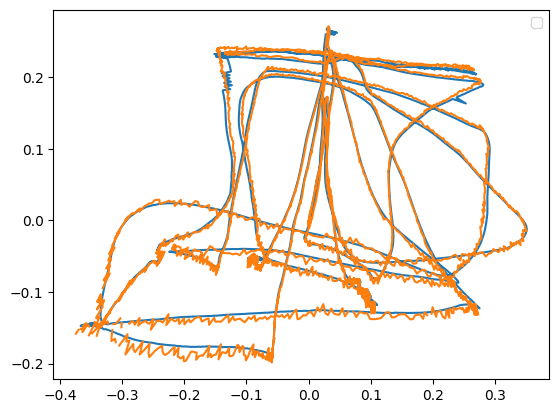

In [32]:
plt.plot(aligned_mocap[:,0], aligned_mocap[:,2])
# plt.plot(mocap_x, mocap_z)
plt.plot(tvec_transformed[:, 0], tvec_transformed[:, 2])
plt.legend()
plt.show()

### Evaluating a section to see everything is right

In [53]:
all_corners_list = []
corner_counts = []
print("Filtering corners for ID 12...")
for _corner, _id in zip(ar_corners, ids):
    try:
        id_index = _id.reshape(-1).tolist().index(12)
        all_corners_list.append(np.array(_corner[id_index]).reshape(-1, 2))
        corner_counts.append(len(np.array(_corner[id_index]).reshape(-1, 2)))
    except:
        corner_counts.append(0)
all_corners_concat = np.vstack(all_corners_list).reshape(-1, 1, 2)

_i = min_index
fish_mat = my_dict["mat"][_i]
fish_dist = my_dict["dist"][_i]
if useFisheye:

    _new_cam = cv2.fisheye.estimateNewCameraMatrixForUndistortRectify(
        fish_mat, fish_dist, (1280, 800), np.eye(3), balance=1
    )
    
    # Batch undistort
    undist_all = cv2.fisheye.undistortPoints(
        all_corners_concat, fish_mat, fish_dist, None, _new_cam
    )
else:
    _new_cam = fish_mat
    fish_dist = fish_dist[:4]
    undist_all = all_corners_concat

# Split back into individual corner sets
undist_corners = []
idx = 0
for count in corner_counts:
    if count > 0:
        undist_corners.append(undist_all[idx:idx+count])
        idx += count
    else:
        undist_corners.append(None)

# Pre-allocate arrays
num_markers = len(undist_corners)
rvecs = np.full((num_markers, 3), np.nan)
tvecs = np.full((num_markers, 3), np.nan)

for idx, _c in enumerate(undist_corners):
    if _c is not None:  # Already filtered for ID 12
        num_detected_markers = _c.shape[0] // 4
        reshaped_corners = [
            _c[j * 4:(j + 1) * 4].reshape(4, 1, 2)
            for j in range(num_detected_markers)
        ]
        
        rotation_vectors, translation_vectors = estimate_pose_single_markers(
            corners=reshaped_corners,
            marker_size=0.047,
            camera_matrix=_new_cam,
            distortion_coefficients=fish_dist,
        )
        
        if rotation_vectors is not None and len(rotation_vectors) > 0:
            rvecs[idx] = rotation_vectors[0][0]
            tvecs[idx] = translation_vectors[0][0]

# Find first valid (non-NaN) marker to use as reference
valid_idx = None
for idx in range(len(rvecs)):
    if not np.isnan(rvecs[idx]).any():
        valid_idx = idx
        break

# Vectorize transformation calculations using first valid marker as reference
rmat = cv2.Rodrigues(rvecs[valid_idx])[0]
rmat_T = rmat.T

# Vectorized translation transformation
tvec_diff = tvecs - tvecs[valid_idx]
tvec_transformed = (rmat_T @ tvec_diff.T).T

# axis flipped
transformed_tvecs = tvec_transformed.copy()

# Vectorize error calculations
_ex = np.nanmean(np.abs(transformed_tvecs[:, 0] - aligned_mocap[:,0]))
_ey = np.nanmean(np.abs(transformed_tvecs[:, 1] - aligned_mocap[:,1]))
_ez = np.nanmean(np.abs(transformed_tvecs[:, 2] - aligned_mocap[:,2]))

_mean_err = np.nanmean([_ex, _ey, _ez])

# filtering out 95th percentile

_ex_arr = np.abs(transformed_tvecs[:, 0] - aligned_mocap[:,0])
_px = np.nanpercentile(_ex_arr, 95)
_ex_p = np.nanmax(_ex_arr[_ex_arr <= _px])

_ey_arr = np.abs(transformed_tvecs[:, 1] - aligned_mocap[:,1])
_py = np.nanpercentile(_ey_arr, 95)
_ey_p = np.nanmax(_ey_arr[_ey_arr <= _py])

_ez_arr = np.abs(transformed_tvecs[:, 2] - aligned_mocap[:,2])
_pz = np.nanpercentile(_ez_arr, 95)
_ez_p = np.nanmax(_ez_arr[_ez_arr <= _pz])

_max_x = np.nanmax(np.abs(transformed_tvecs[:, 0] - aligned_mocap[:,0]))
_max_y = np.nanmax(np.abs(transformed_tvecs[:, 1] - aligned_mocap[:,1]))
_max_z = np.nanmax(np.abs(transformed_tvecs[:, 2] - aligned_mocap[:,2]))

print(f"Max error: X={_max_x}, Y={_max_y}, Z={_max_z}")
print(f"Max error 95th percentile: X={_ex_p}, Y={_ey_p}, Z={_ez_p}")

Filtering corners for ID 12...
Max error: X=0.021951615483940423, Y=0.0039907723850845095, Z=0.0218619882382782
Max error 95th percentile: X=0.005820514655501624, Y=0.0022543097958233893, Z=0.00828243220792875


In [116]:
all_corners_list = []
corner_counts = []
print("Filtering corners for ID 12...")
for _corner, _id in zip(ar_corners, ids):
    try:
        id_index = _id.reshape(-1).tolist().index(12)
        all_corners_list.append(np.array(_corner[id_index]).reshape(-1, 2))
        corner_counts.append(len(np.array(_corner[id_index]).reshape(-1, 2)))
    except:
        corner_counts.append(0)
all_corners_concat = np.vstack(all_corners_list).reshape(-1, 1, 2)

_i = min_index
fish_mat = my_dict["mat"][_i]
fish_dist = my_dict["dist"][_i]
if useFisheye:

    _new_cam = cv2.fisheye.estimateNewCameraMatrixForUndistortRectify(
        fish_mat, fish_dist, (1280, 800), np.eye(3), balance=1
    )
    
    # Batch undistort
    undist_all = cv2.fisheye.undistortPoints(
        all_corners_concat, fish_mat, fish_dist, None, _new_cam
    )
else:
    _new_cam = fish_mat
    fish_dist = fish_dist[:4]
    undist_all = all_corners_concat

# Split back into individual corner sets
undist_corners = []
idx = 0
for count in corner_counts:
    if count > 0:
        undist_corners.append(undist_all[idx:idx+count])
        idx += count
    else:
        undist_corners.append(None)

# Pre-allocate arrays
num_markers = len(undist_corners)
rvecs = np.full((num_markers, 3), np.nan)
tvecs = np.full((num_markers, 3), np.nan)

for idx, _c in enumerate(undist_corners):
    if _c is not None:  # Already filtered for ID 12
        num_detected_markers = _c.shape[0] // 4
        reshaped_corners = [
            _c[j * 4:(j + 1) * 4].reshape(4, 1, 2)
            for j in range(num_detected_markers)
        ]
        
        rotation_vectors, translation_vectors = estimate_pose_single_markers(
            corners=reshaped_corners,
            marker_size=0.047,
            camera_matrix=_new_cam,
            distortion_coefficients=fish_dist,
        )
        
        if rotation_vectors is not None and len(rotation_vectors) > 0:
            rvecs[idx] = rotation_vectors[0][0]
            tvecs[idx] = translation_vectors[0][0]

# Find first valid (non-NaN) marker to use as reference
valid_idx = None
for idx in range(len(rvecs)):
    if not np.isnan(rvecs[idx]).any():
        valid_idx = idx
        break

# Vectorize transformation calculations using first valid marker as reference
rmat = cv2.Rodrigues(rvecs[valid_idx])[0]
rmat_T = rmat.T

# for reconstruction

_h_offset = np.array([0,0,0.05]).reshape(3,1)

_h_offset = _offset_tvvv
_newtvec = []
for _rr, _tt in zip(rvecs, tvecs):
    _rt = (cv2.Rodrigues(_rr)[0] @ _h_offset + _tt).T[0]
    _newtvec.append(_rt)

_newtvec = np.array(_newtvec)

# Vectorized translation transformation
tvec_diff = _newtvec - _newtvec[valid_idx]
tvec_transformed = (rmat_T @ tvec_diff.T).T

# axis flipped
transformed_tvecs = tvec_transformed.copy()

# Vectorize error calculations
_ex = np.nanmean(np.abs(transformed_tvecs[:, 0] - aligned_mocap[:,0]))
_ey = np.nanmean(np.abs(transformed_tvecs[:, 1] - aligned_mocap[:,1]))
_ez = np.nanmean(np.abs(transformed_tvecs[:, 2] - aligned_mocap[:,2]))

_mean_err = np.nanmean([_ex, _ey, _ez])

# filtering out 95th percentile

_ex_arr = np.abs(transformed_tvecs[:, 0] - aligned_mocap[:,0])
_px = np.nanpercentile(_ex_arr, 95)
_ex_p = np.nanmax(_ex_arr[_ex_arr <= _px])

_ey_arr = np.abs(transformed_tvecs[:, 1] - aligned_mocap[:,1])
_py = np.nanpercentile(_ey_arr, 95)
_ey_p = np.nanmax(_ey_arr[_ey_arr <= _py])

_ez_arr = np.abs(transformed_tvecs[:, 2] - aligned_mocap[:,2])
_pz = np.nanpercentile(_ez_arr, 95)
_ez_p = np.nanmax(_ez_arr[_ez_arr <= _pz])

_max_x = np.nanmax(np.abs(transformed_tvecs[:, 0] - aligned_mocap[:,0]))
_max_y = np.nanmax(np.abs(transformed_tvecs[:, 1] - aligned_mocap[:,1]))
_max_z = np.nanmax(np.abs(transformed_tvecs[:, 2] - aligned_mocap[:,2]))

print(f"Max error: X={_max_x}, Y={_max_y}, Z={_max_z}")
print(f"Max error 95th percentile: X={_ex_p}, Y={_ey_p}, Z={_ez_p}")

Filtering corners for ID 12...
Max error: X=0.16159038628665717, Y=0.48762731963465167, Z=0.49573239625669535
Max error 95th percentile: X=0.03806892005990867, Y=0.3622280687814435, Z=0.41412062992364496


In [82]:
tvec_diff

array([[ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       ...,
       [-0.06142086, -0.06648991, -0.07286566],
       [-0.06832439, -0.07924551, -0.07640524],
       [-0.06832439, -0.07924551, -0.07640524]], shape=(4018, 3))

In [60]:
from scipy.spatial.transform import Rotation as R_scipy

# ─────────────────────────────────────────────────────────────────
# 1. Extract quaternions and sanitize zero/NaN rows first
# ─────────────────────────────────────────────────────────────────
mocap_quats_all = mocap_df[["rb_ang_x", "rb_ang_y", "rb_ang_z", "rb_ang_w"]].to_numpy().astype(float)

# Identify bad rows: zero norm OR any NaN
quat_norms = np.linalg.norm(mocap_quats_all, axis=1)
bad_quat_mask = (quat_norms < 1e-6) | np.any(np.isnan(mocap_quats_all), axis=1)

print(f"Bad quaternion frames (dropout): {bad_quat_mask.sum()} / {len(mocap_quats_all)}")

# Replace bad rows with NaN so frame indices stay aligned
mocap_quats_clean = mocap_quats_all.copy()
mocap_quats_clean[bad_quat_mask] = np.nan

# Convert only valid rows
mocap_rotmats_all = np.full((len(mocap_quats_clean), 3, 3), np.nan)
valid_quat_mask = ~bad_quat_mask
mocap_rotmats_all[valid_quat_mask] = R_scipy.from_quat(
    mocap_quats_clean[valid_quat_mask]
).as_matrix()

R_mocap_0 = mocap_rotmats_all[0]

# ─────────────────────────────────────────────────────────────────
# 2. Relative mocap orientations — skip bad frames
# ─────────────────────────────────────────────────────────────────
mocap_rotmats_rel = np.full_like(mocap_rotmats_all, np.nan)
for i in range(len(mocap_rotmats_all)):
    if not np.isnan(mocap_rotmats_all[i]).any():
        mocap_rotmats_rel[i] = R_mocap_0.T @ mocap_rotmats_all[i]

# ─────────────────────────────────────────────────────────────────
# 2. Convert ArUco rvecs → rotation matrices relative to valid_idx
#    (mirrors your tvec_diff @ rmat_T logic for position)
# ─────────────────────────────────────────────────────────────────
R_aruco_ref = cv2.Rodrigues(rvecs[valid_idx])[0]   # same rmat you already computed

aruco_rotmats_rel = np.full((len(rvecs), 3, 3), np.nan)
for i, rv in enumerate(rvecs):
    if not np.isnan(rv).any():
        Ri = cv2.Rodrigues(rv)[0]
        aruco_rotmats_rel[i] = R_aruco_ref.T @ Ri   # relative rotation

# ─────────────────────────────────────────────────────────────────
# 3. Apply Kabsch R_opt so ArUco sits in the same frame as mocap
#    (same R_opt you used for aligned_mocap position)
# ─────────────────────────────────────────────────────────────────
aruco_rotmats_aligned = np.full_like(aruco_rotmats_rel, np.nan)
for i in range(len(aruco_rotmats_rel)):
    if not np.isnan(aruco_rotmats_rel[i]).any():
        aruco_rotmats_aligned[i] = R_opt @ aruco_rotmats_rel[i]

# ─────────────────────────────────────────────────────────────────
# 4. Geodesic angular error per frame
# ─────────────────────────────────────────────────────────────────
def geodesic_error_deg(R1, R2):
    R_diff = R1.T @ R2
    cos_angle = np.clip((np.trace(R_diff) - 1.0) / 2.0, -1.0, 1.0)
    return np.degrees(np.arccos(cos_angle))

# ─────────────────────────────────────────────────────────────────
# Guard: align array lengths before any comparison
# ─────────────────────────────────────────────────────────────────
n_frames = min(len(aruco_rotmats_aligned), len(mocap_rotmats_rel))
print(f"ArUco frames: {len(aruco_rotmats_aligned)}, Mocap frames: {len(mocap_rotmats_rel)}, Using: {n_frames}")

angle_errors = np.full(n_frames, np.nan)
for i in range(n_frames):
    if (not np.isnan(aruco_rotmats_aligned[i]).any() and
            not np.isnan(mocap_rotmats_rel[i]).any()):
        angle_errors[i] = geodesic_error_deg(
            aruco_rotmats_aligned[i], mocap_rotmats_rel[i]
        )

euler_errors = np.full((n_frames, 3), np.nan)
for i in range(n_frames):
    if (not np.isnan(aruco_rotmats_aligned[i]).any() and
            not np.isnan(mocap_rotmats_rel[i]).any()):
        R_diff = aruco_rotmats_aligned[i].T @ mocap_rotmats_rel[i]
        euler_errors[i] = R_scipy.from_matrix(R_diff).as_euler('xyz', degrees=True)
    

# ─────────────────────────────────────────────────────────────────
# 5. Summary stats — same style as your translation errors
# ─────────────────────────────────────────────────────────────────
_mean_rot_err   = np.nanmean(angle_errors)
_median_rot_err = np.nanmedian(angle_errors)
_p95_rot_err    = np.nanpercentile(angle_errors, 95)
_max_rot_err    = np.nanmax(angle_errors)

print(f"Orientation error (geodesic):")
print(f"  Mean:   {_mean_rot_err:.3f}°")
print(f"  Median: {_median_rot_err:.3f}°")
print(f"  95th %: {_p95_rot_err:.3f}°")
print(f"  Max:    {_max_rot_err:.3f}°")

# ─────────────────────────────────────────────────────────────────
# 6. Per-axis Euler breakdown — pinpoints which axis drifts most
# ─────────────────────────────────────────────────────────────────
euler_errors = np.full((len(aruco_rotmats_aligned), 3), np.nan)
for i in range(len(aruco_rotmats_aligned)):
    if not np.isnan(aruco_rotmats_aligned[i]).any():
        R_diff = aruco_rotmats_aligned[i].T @ mocap_rotmats_rel[i]
        euler_errors[i] = R_scipy.from_matrix(R_diff).as_euler('xyz', degrees=True)

print(f"\nPer-axis Euler error (mean absolute):")
print(f"  X: {np.nanmean(np.abs(euler_errors[:, 0])):.3f}°")
print(f"  Y: {np.nanmean(np.abs(euler_errors[:, 1])):.3f}°")
print(f"  Z: {np.nanmean(np.abs(euler_errors[:, 2])):.3f}°")

Bad quaternion frames (dropout): 1 / 4009
ArUco frames: 4018, Mocap frames: 4009, Using: 4009
Orientation error (geodesic):
  Mean:   140.068°
  Median: 140.405°
  95th %: 144.088°
  Max:    170.906°


c:\Users\Pintu\miniconda3\envs\py13\Lib\site-packages\numpy\linalg\_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


LinAlgError: SVD did not converge

X (Roll)  |  Mocap range: [-179.5°, 179.8°]  |  ArUco range: [94.9°, 132.4°]
Y (Pitch)  |  Mocap range: [-19.9°, 7.0°]  |  ArUco range: [-27.3°, 26.6°]
Z (Yaw)  |  Mocap range: [-11.2°, 12.1°]  |  ArUco range: [41.5°, 176.3°]


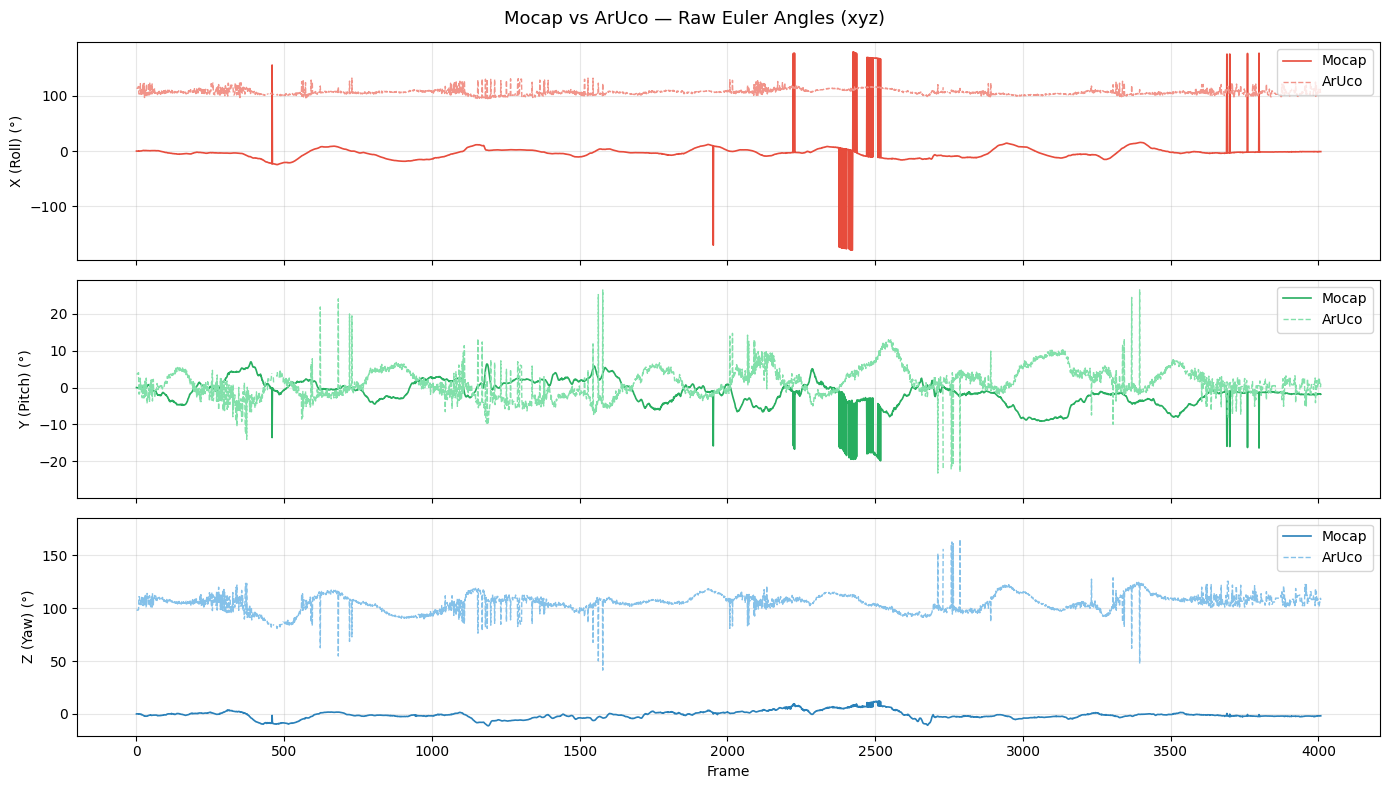

In [61]:
# ─────────────────────────────────────────────────────────────────
# Extract raw Euler angles from both systems for direct comparison
# ─────────────────────────────────────────────────────────────────

# Mocap: convert relative rotation matrices → Euler xyz
mocap_euler = np.full((n_frames, 3), np.nan)
for i in range(n_frames):
    if not np.isnan(mocap_rotmats_rel[i]).any():
        mocap_euler[i] = R_scipy.from_matrix(mocap_rotmats_rel[i]).as_euler('xyz', degrees=True)

# ArUco: convert aligned rotation matrices → Euler xyz
aruco_euler = np.full((n_frames, 3), np.nan)
for i in range(n_frames):
    if not np.isnan(aruco_rotmats_aligned[i]).any():
        aruco_euler[i] = R_scipy.from_matrix(aruco_rotmats_aligned[i]).as_euler('xyz', degrees=True)

# ─────────────────────────────────────────────────────────────────
# Plot side by side for each axis
# ─────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
axis_labels = ['X (Roll)', 'Y (Pitch)', 'Z (Yaw)']
colors_mocap  = ['#e74c3c', '#27ae60', '#2980b9']
colors_aruco  = ['#f1948a', '#82e0aa', '#85c1e9']

for ax, j, label, cm, ca in zip(axes, range(3), axis_labels, colors_mocap, colors_aruco):
    ax.plot(mocap_euler[:, j],  color=cm, label='Mocap',  linewidth=1.2)
    ax.plot(aruco_euler[:, j],  color=ca, label='ArUco',  linewidth=1.0, linestyle='--')
    ax.set_ylabel(f'{label} (°)')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    # Print range info to spot scale/sign issues
    print(f"{label}  |  Mocap range: [{np.nanmin(mocap_euler[:,j]):.1f}°, {np.nanmax(mocap_euler[:,j]):.1f}°]"
          f"  |  ArUco range: [{np.nanmin(aruco_euler[:,j]):.1f}°, {np.nanmax(aruco_euler[:,j]):.1f}°]")

axes[-1].set_xlabel('Frame')
fig.suptitle('Mocap vs ArUco — Raw Euler Angles (xyz)', fontsize=13)
plt.tight_layout()
plt.show()

Estimated frame offset (xyz Euler):
  X: 136.98°  Y: -65.43°  Z: 132.93°
X (Roll)  |  Mocap: [-179.5°, 179.8°]  |  ArUco corrected: [-32.3°, 24.1°]
Y (Pitch)  |  Mocap: [-19.9°, 7.0°]  |  ArUco corrected: [-11.6°, 21.2°]
Z (Yaw)  |  Mocap: [-11.2°, 12.1°]  |  ArUco corrected: [-69.6°, 70.6°]


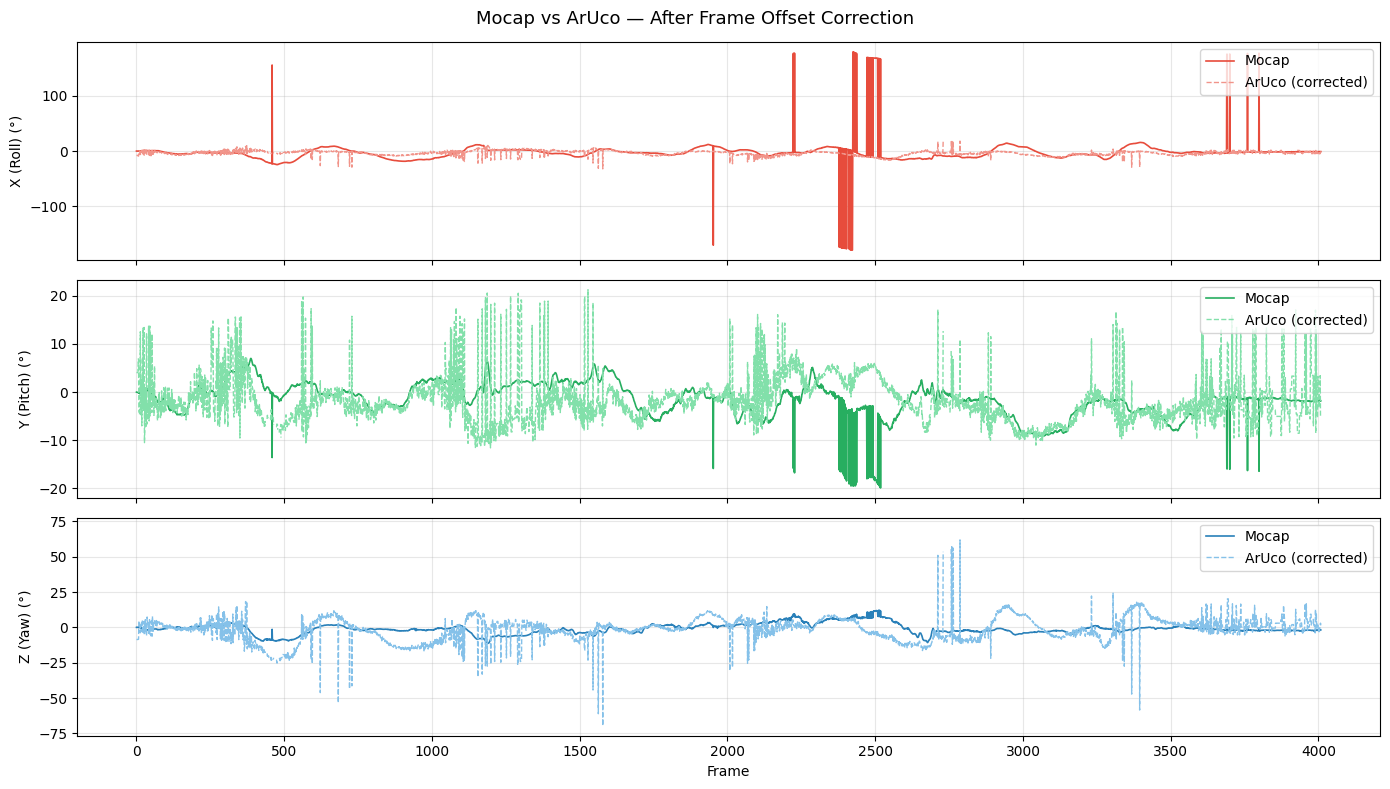


Orientation error after correction (geodesic):
  Mean:   12.630°
  Median: 8.754°
  95th %: 22.377°
  Max:    179.645°


In [62]:
# ─────────────────────────────────────────────────────────────────
# Find the fixed frame offset between ArUco and mocap orientations
# Use mean rotation over all valid frames (robust vs single frame)
# ─────────────────────────────────────────────────────────────────
valid_frames = [
    i for i in range(n_frames)
    if not np.isnan(aruco_rotmats_aligned[i]).any()
    and not np.isnan(mocap_rotmats_rel[i]).any()
]

R_diffs = np.array([
    aruco_rotmats_aligned[i].T @ mocap_rotmats_rel[i]
    for i in valid_frames
])

# scipy's mean() averages rotations correctly on SO(3) manifold
R_offset = R_scipy.from_matrix(R_diffs).mean().as_matrix()

euler_offset = R_scipy.from_matrix(R_offset).as_euler('xyz', degrees=True)
print(f"Estimated frame offset (xyz Euler):")
print(f"  X: {euler_offset[0]:.2f}°  Y: {euler_offset[1]:.2f}°  Z: {euler_offset[2]:.2f}°")

# ─────────────────────────────────────────────────────────────────
# Apply offset correction to ArUco rotations
# ─────────────────────────────────────────────────────────────────
aruco_rotmats_corrected = np.full_like(aruco_rotmats_aligned, np.nan)
for i in range(n_frames):
    if not np.isnan(aruco_rotmats_aligned[i]).any():
        aruco_rotmats_corrected[i] = aruco_rotmats_aligned[i] @ R_offset

# ─────────────────────────────────────────────────────────────────
# Re-extract Euler angles and re-plot to verify alignment
# ─────────────────────────────────────────────────────────────────
aruco_euler_corrected = np.full((n_frames, 3), np.nan)
for i in range(n_frames):
    if not np.isnan(aruco_rotmats_corrected[i]).any():
        aruco_euler_corrected[i] = R_scipy.from_matrix(
            aruco_rotmats_corrected[i]
        ).as_euler('xyz', degrees=True)

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
axis_labels = ['X (Roll)', 'Y (Pitch)', 'Z (Yaw)']
colors_mocap = ['#e74c3c', '#27ae60', '#2980b9']
colors_aruco = ['#f1948a', '#82e0aa', '#85c1e9']

for ax, j, label, cm, ca in zip(axes, range(3), axis_labels, colors_mocap, colors_aruco):
    ax.plot(mocap_euler[:, j], color=cm, label='Mocap', linewidth=1.2)
    ax.plot(aruco_euler_corrected[:, j], color=ca, label='ArUco (corrected)', linewidth=1.0, linestyle='--')
    ax.set_ylabel(f'{label} (°)')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    print(f"{label}  |  Mocap: [{np.nanmin(mocap_euler[:,j]):.1f}°, {np.nanmax(mocap_euler[:,j]):.1f}°]"
          f"  |  ArUco corrected: [{np.nanmin(aruco_euler_corrected[:,j]):.1f}°, {np.nanmax(aruco_euler_corrected[:,j]):.1f}°]")

axes[-1].set_xlabel('Frame')
fig.suptitle('Mocap vs ArUco — After Frame Offset Correction', fontsize=13)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────
# Recompute geodesic errors with corrected rotations
# ─────────────────────────────────────────────────────────────────
angle_errors_corrected = np.full(n_frames, np.nan)
for i in range(n_frames):
    if (not np.isnan(aruco_rotmats_corrected[i]).any() and
            not np.isnan(mocap_rotmats_rel[i]).any()):
        angle_errors_corrected[i] = geodesic_error_deg(
            aruco_rotmats_corrected[i], mocap_rotmats_rel[i]
        )

print(f"\nOrientation error after correction (geodesic):")
print(f"  Mean:   {np.nanmean(angle_errors_corrected):.3f}°")
print(f"  Median: {np.nanmedian(angle_errors_corrected):.3f}°")
print(f"  95th %: {np.nanpercentile(angle_errors_corrected, 95):.3f}°")
print(f"  Max:    {np.nanmax(angle_errors_corrected):.3f}°")

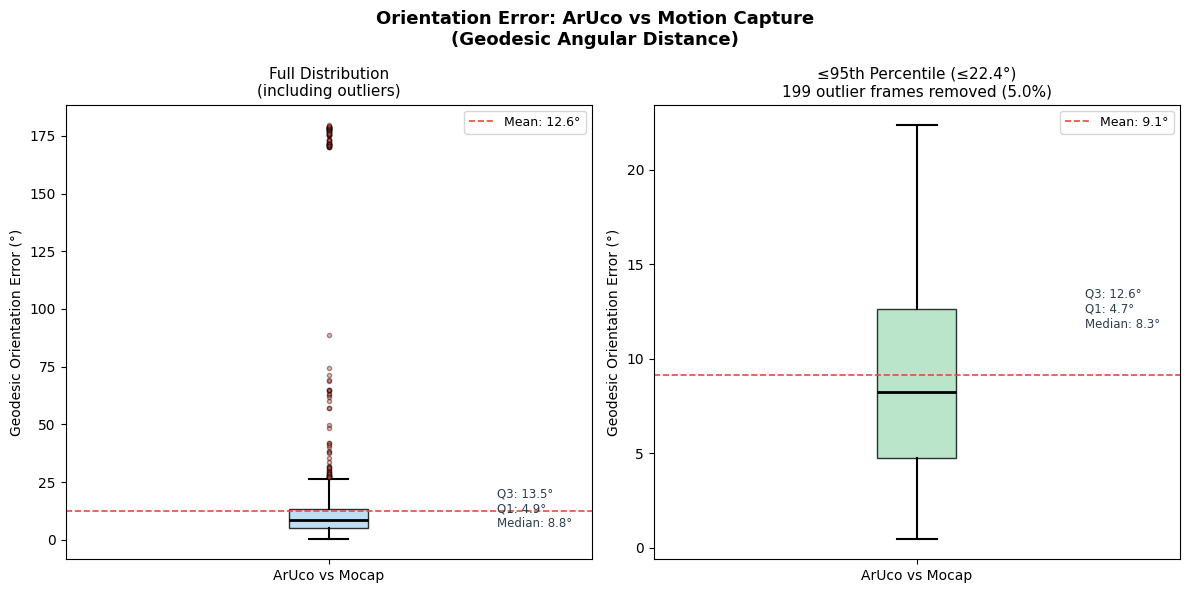


Full distribution  — Mean: 12.63°  Median: 8.75°
≤95th percentile   — Mean: 9.15°  Median: 8.27°
Outliers (>22.4°): 199 frames (5.0%)


In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# ── Raw data with outliers flagged ──────────────────────────────
valid_errors = angle_errors_corrected[~np.isnan(angle_errors_corrected)]
p95 = np.nanpercentile(angle_errors_corrected, 95)
clean_errors = valid_errors[valid_errors <= p95]

n_outliers = np.sum(valid_errors > p95)
n_total = len(valid_errors)

# ── Left: full distribution ──────────────────────────────────────
bp1 = axes[0].boxplot(
    valid_errors,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=3, alpha=0.4),
    boxprops=dict(facecolor='#aed6f1', alpha=0.8),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
)
axes[0].set_title('Full Distribution\n(including outliers)', fontsize=11)
axes[0].set_ylabel('Geodesic Orientation Error (°)')
axes[0].set_xticks([1])
axes[0].set_xticklabels(['ArUco vs Mocap'])

# Annotate stats
axes[0].axhline(np.mean(valid_errors), color='#e74c3c', linestyle='--', linewidth=1.2, label=f'Mean: {np.mean(valid_errors):.1f}°')
axes[0].legend(fontsize=9)
axes[0].text(1.32, np.percentile(valid_errors, 75),
             f'Q3: {np.percentile(valid_errors, 75):.1f}°\nQ1: {np.percentile(valid_errors, 25):.1f}°\nMedian: {np.median(valid_errors):.1f}°',
             fontsize=8.5, va='center', color='#2c3e50')

# ── Right: 95th percentile clipped ──────────────────────────────
bp2 = axes[1].boxplot(
    clean_errors,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=3, alpha=0.4),
    boxprops=dict(facecolor='#a9dfbf', alpha=0.8),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
)
axes[1].set_title(f'≤95th Percentile (≤{p95:.1f}°)\n{n_outliers} outlier frames removed ({100*n_outliers/n_total:.1f}%)', fontsize=11)
axes[1].set_ylabel('Geodesic Orientation Error (°)')
axes[1].set_xticks([1])
axes[1].set_xticklabels(['ArUco vs Mocap'])

axes[1].axhline(np.mean(clean_errors), color='#e74c3c', linestyle='--', linewidth=1.2, label=f'Mean: {np.mean(clean_errors):.1f}°')
axes[1].legend(fontsize=9)
axes[1].text(1.32, np.percentile(clean_errors, 75),
             f'Q3: {np.percentile(clean_errors, 75):.1f}°\nQ1: {np.percentile(clean_errors, 25):.1f}°\nMedian: {np.median(clean_errors):.1f}°',
             fontsize=8.5, va='center', color='#2c3e50')

fig.suptitle('Orientation Error: ArUco vs Motion Capture\n(Geodesic Angular Distance)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nFull distribution  — Mean: {np.mean(valid_errors):.2f}°  Median: {np.median(valid_errors):.2f}°")
print(f"≤95th percentile   — Mean: {np.mean(clean_errors):.2f}°  Median: {np.median(clean_errors):.2f}°")
print(f"Outliers (>{p95:.1f}°): {n_outliers} frames ({100*n_outliers/n_total:.1f}%)")

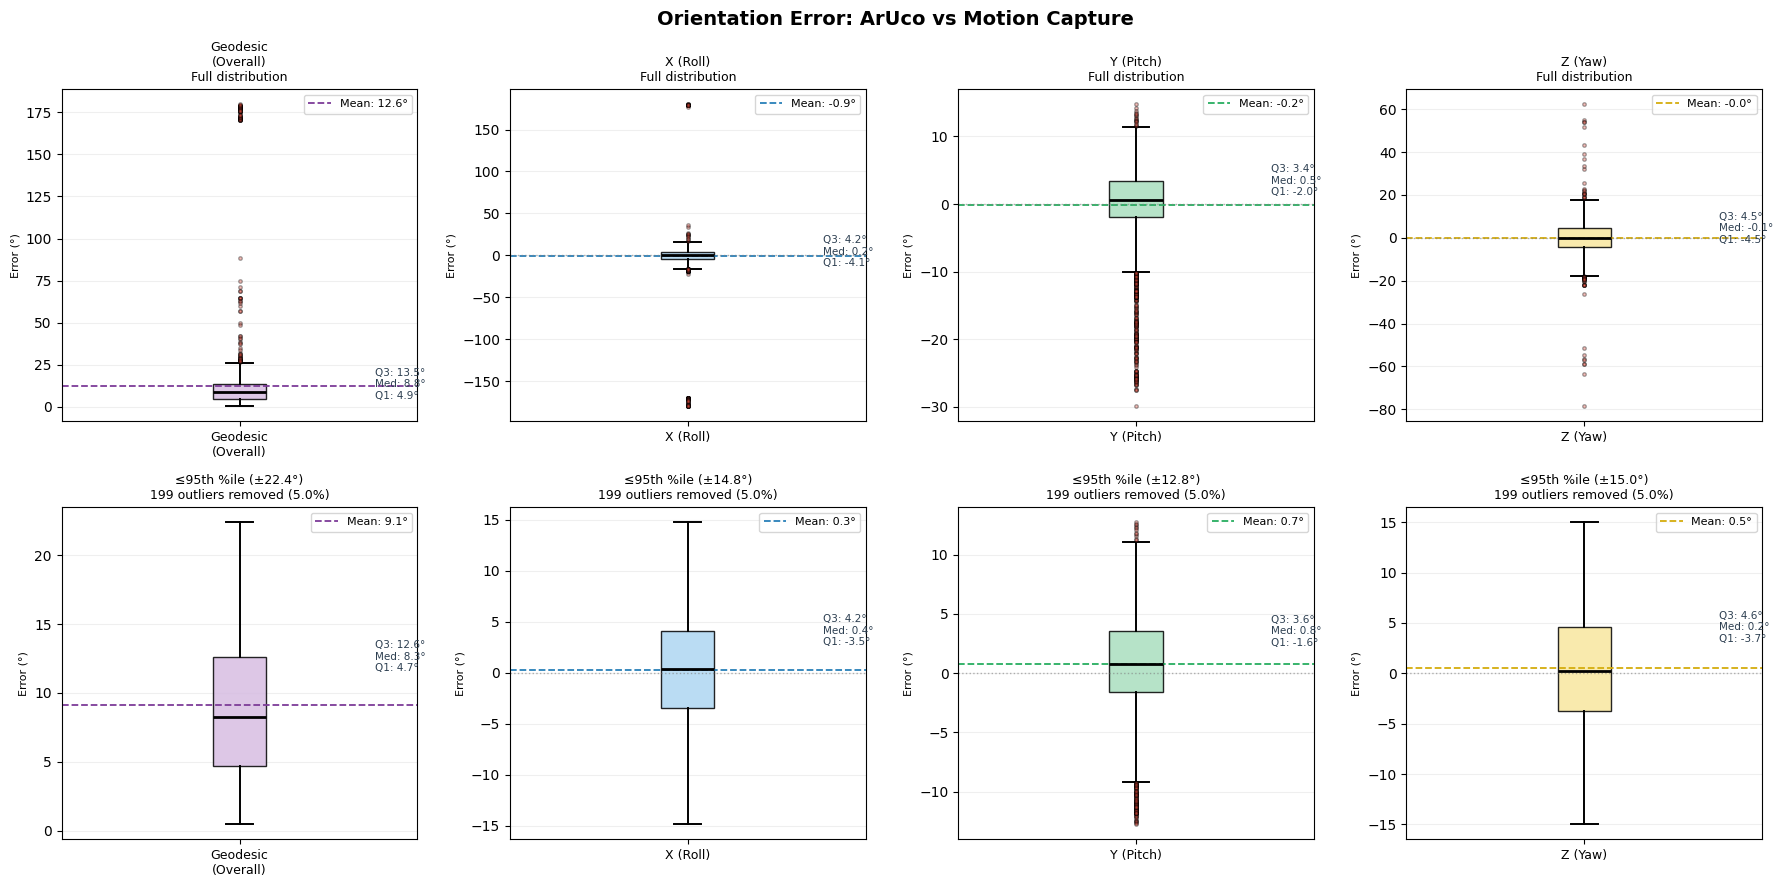

Axis           Mean abs   Median abs  95th %ile    Max abs
──────────────────────────────────────────────────────────
Geodesic         12.63°        8.75°     22.38°    179.64°
Roll (X)          8.10°        4.14°     14.84°    179.94°
Pitch (Y)         4.17°        2.85°     12.76°     29.92°
Yaw (Z)           5.88°        4.48°     14.99°     78.55°


In [65]:
# ─────────────────────────────────────────────────────────────────
# Recompute per-axis Euler errors using corrected rotations
# ─────────────────────────────────────────────────────────────────
euler_errors_corrected = np.full((n_frames, 3), np.nan)
for i in range(n_frames):
    if (not np.isnan(aruco_rotmats_corrected[i]).any() and
            not np.isnan(mocap_rotmats_rel[i]).any()):
        R_diff = aruco_rotmats_corrected[i].T @ mocap_rotmats_rel[i]
        euler_errors_corrected[i] = R_scipy.from_matrix(R_diff).as_euler('xyz', degrees=True)

# ─────────────────────────────────────────────────────────────────
# Build per-axis clipped arrays (≤95th percentile of abs error)
# ─────────────────────────────────────────────────────────────────
axis_labels  = ['X (Roll)', 'Y (Pitch)', 'Z (Yaw)']
colors_box   = ['#aed6f1', '#a9dfbf', '#f9e79f']
colors_mean  = ['#2980b9', '#27ae60', '#d4ac0d']

p95_geodesic = np.nanpercentile(angle_errors_corrected, 95)

data_full  = []   # raw signed errors per axis
data_clean = []   # ≤95th percentile of |error|

for j in range(3):
    raw = euler_errors_corrected[:, j]
    valid = raw[~np.isnan(raw)]
    p95_j = np.nanpercentile(np.abs(valid), 95)
    clean = valid[np.abs(valid) <= p95_j]
    data_full.append(valid)
    data_clean.append(clean)

# ─────────────────────────────────────────────────────────────────
# Plot: 4 columns — Geodesic + Roll + Pitch + Yaw
# Each column: full (top) and ≤95th (bottom)
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Orientation Error: ArUco vs Motion Capture', fontsize=14, fontweight='bold')

valid_geo   = angle_errors_corrected[~np.isnan(angle_errors_corrected)]
p95_geo     = np.nanpercentile(valid_geo, 95)
clean_geo   = valid_geo[valid_geo <= p95_geo]
n_out_geo   = np.sum(valid_geo > p95_geo)

all_data_full  = [valid_geo]  + data_full
all_data_clean = [clean_geo]  + data_clean
col_labels     = ['Geodesic\n(Overall)', 'X (Roll)', 'Y (Pitch)', 'Z (Yaw)']
col_colors     = ['#d7bde2', '#aed6f1', '#a9dfbf', '#f9e79f']
col_means      = ['#7d3c98', '#2980b9', '#27ae60', '#d4ac0d']

for col in range(4):
    for row, data in enumerate([all_data_full[col], all_data_clean[col]]):
        ax = axes[row, col]
        bp = ax.boxplot(
            data,
            patch_artist=True,
            medianprops=dict(color='black', linewidth=2),
            flierprops=dict(marker='o', markerfacecolor='#e74c3c',
                            markersize=2.5, alpha=0.35),
            boxprops=dict(facecolor=col_colors[col], alpha=0.85),
            whiskerprops=dict(linewidth=1.4),
            capprops=dict(linewidth=1.4),
        )
        mean_val = np.mean(data)
        ax.axhline(mean_val, color=col_means[col], linestyle='--',
                   linewidth=1.3, label=f'Mean: {mean_val:.1f}°')

        # Zero reference line for signed Euler plots
        if col > 0:
            ax.axhline(0, color='grey', linestyle=':', linewidth=1.0, alpha=0.6)

        # Stats annotation
        q1, med, q3 = np.percentile(data, [25, 50, 75])
        ax.text(1.38, q3,
                f'Q3: {q3:.1f}°\nMed: {med:.1f}°\nQ1: {q1:.1f}°',
                fontsize=7.5, va='center', color='#2c3e50')

        ax.set_xticks([1])
        ax.set_xticklabels([col_labels[col]], fontsize=9)
        ax.set_ylabel('Error (°)', fontsize=8)
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(True, alpha=0.2, axis='y')

        if row == 0:
            ax.set_title(f'{col_labels[col]}\nFull distribution', fontsize=9)
        else:
            p95_val = np.nanpercentile(np.abs(all_data_full[col]), 95)
            n_out   = np.sum(np.abs(all_data_full[col]) > p95_val)
            n_tot   = len(all_data_full[col])
            ax.set_title(f'≤95th %ile (±{p95_val:.1f}°)\n{n_out} outliers removed ({100*n_out/n_tot:.1f}%)', fontsize=9)

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────
# Summary table
# ─────────────────────────────────────────────────────────────────
print(f"{'Axis':<12} {'Mean abs':>10} {'Median abs':>12} {'95th %ile':>10} {'Max abs':>10}")
print("─" * 58)
names = ['Geodesic', 'Roll (X)', 'Pitch (Y)', 'Yaw (Z)']
for name, full in zip(names, all_data_full):
    abs_data = np.abs(full)
    print(f"{name:<12} {np.mean(abs_data):>9.2f}°  {np.median(abs_data):>10.2f}°"
          f"  {np.nanpercentile(abs_data, 95):>8.2f}°  {np.max(abs_data):>8.2f}°")

## since NOARK + is plannar, we only need to see, y and z, the axis is kind of flipped.

In [117]:
ar_df['time']

time
datetime[μs]
2026-02-12 17:29:59.416
2026-02-12 17:29:59.423913
2026-02-12 17:29:59.433548
2026-02-12 17:29:59.443826
2026-02-12 17:29:59.454139
…
2026-02-12 17:30:39.569491
2026-02-12 17:30:39.580737
2026-02-12 17:30:39.590033


In [52]:
print('Z', np.nanmax(np.abs(tvec_transformed[:, 2]  - aligned_mocap[:,2])))
print('X', np.nanmax(np.abs(tvec_transformed[:, 0]  - mocap_x)))

Z 0.0218619882382782
X 0.41680062294444686


In [118]:
# ── Convert ar_df['time'] to seconds from start ──────────────────
ar_time_us = ar_df['time'].cast(pl.Int64).to_numpy()          # microseconds as int
ar_time_s  = (ar_time_us - ar_time_us[0]) / 1e6               # seconds from t=0

# Trim to match trajectory array length (may differ by 1 frame)
n_traj = min(len(ar_time_s), len(transformed_tvecs), len(aligned_mocap))
t_axis = ar_time_s[:n_traj]

<Figure size 1800x1400 with 0 Axes>

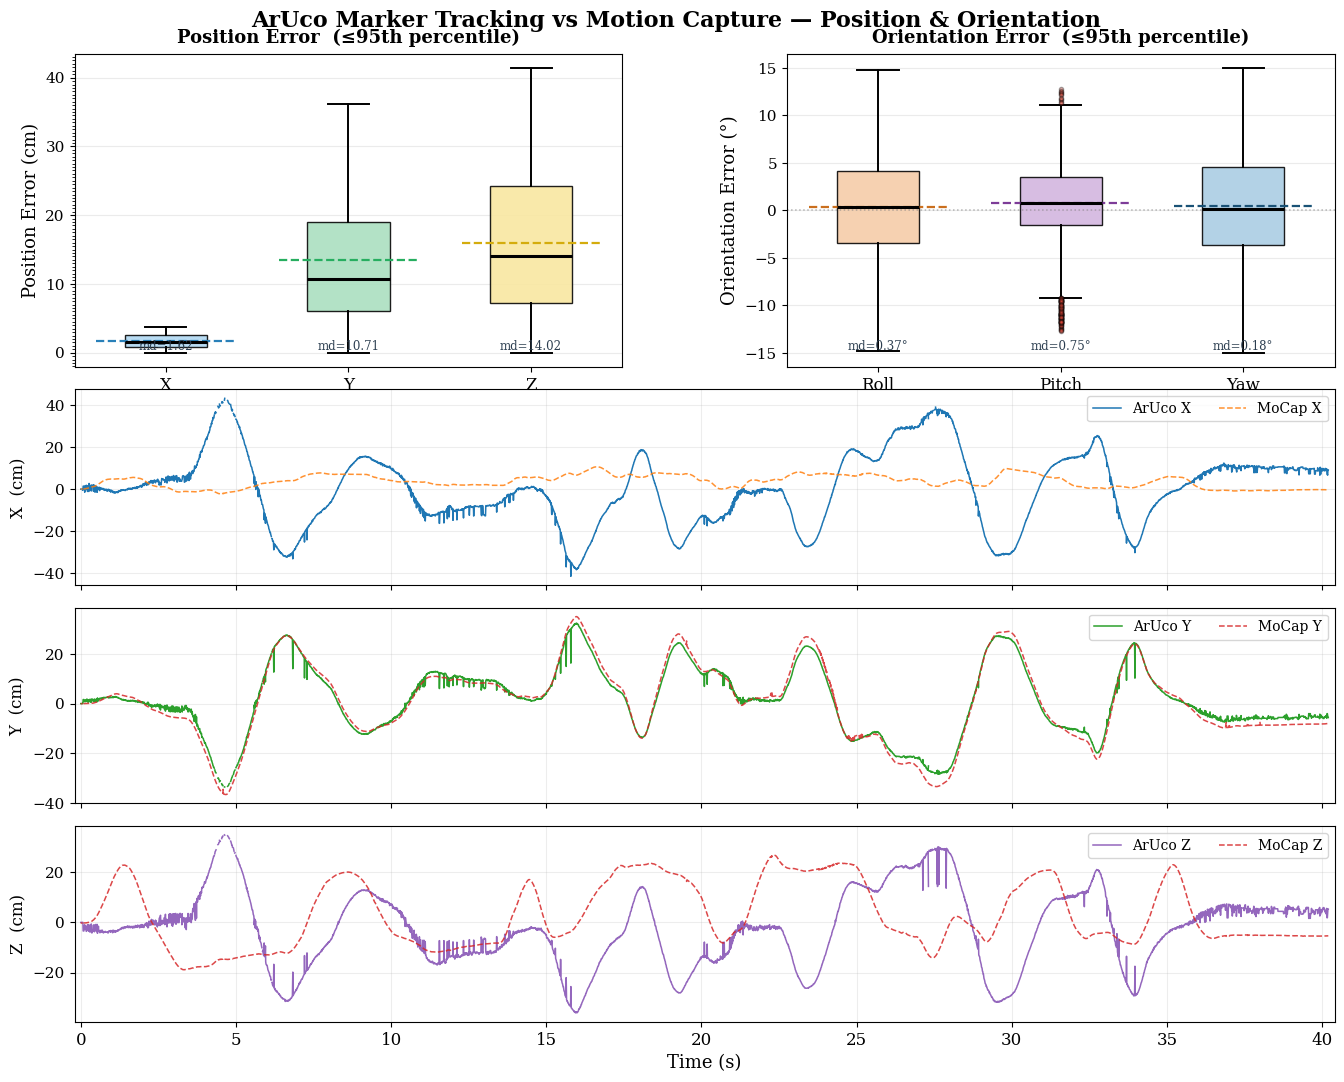

Saved PDF + PNG


In [119]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

plt.rcParams.update({
    'font.size':        13,
    'axes.titlesize':   14,
    'axes.labelsize':   13,
    'xtick.labelsize':  12,
    'ytick.labelsize':  11,
    'legend.fontsize':  11,
    'font.family':      'serif',
})

# ── Prepare data ─────────────────────────────────────────────────
# Position: meters → cm, ≤95th percentile per axis
pos_data, pos_tick_labels = [], ['X', 'Y', 'Z']
for col in range(3):
    raw = np.abs(transformed_tvecs[:, col] - aligned_mocap[:, col]) * 100  # cm
    raw = raw[~np.isnan(raw)]
    p95 = np.nanpercentile(raw, 95)
    pos_data.append(raw[raw <= p95])

# Orientation: signed Euler errors, ≤95th percentile per axis
ori_data, ori_tick_labels = [], ['Roll', 'Pitch', 'Yaw']
for j in range(3):
    raw = euler_errors_corrected[:n_frames, j]
    raw = raw[~np.isnan(raw)]
    p95 = np.nanpercentile(np.abs(raw), 95)
    ori_data.append(raw[np.abs(raw) <= p95])

# ── Layout: 2 box plot cols + 3 tight trajectory rows ────────────
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(
    3, 2,
    figure=fig,
    height_ratios=[1, 1, 1],
    hspace=0.08,          # tight trajectory rows
    wspace=0.32,
)

# Box plots share the top-left and top-right cells;
# trajectories span full width across rows 0-2 on the right side.
# Restructure: left col = box plots stacked, right col = trajectories.
# Actually: top row split 2 cols for boxes, rows 1-3 full width for trajectories.

fig = plt.figure(figsize=(14, 11))
gs  = gridspec.GridSpec(
    4, 2,
    figure=fig,
    height_ratios=[1.6, 1, 1, 1],
    hspace=0.10,
    wspace=0.30,
)

BOX_PROPS = dict(
    patch_artist=True,
    widths=0.45,
    medianprops=dict(color='black', linewidth=2.2),
    whiskerprops=dict(linewidth=1.4),
    capprops=dict(linewidth=1.4),
    flierprops=dict(marker='o', markersize=3, alpha=0.35,
                    markerfacecolor='#e74c3c', linestyle='none'),
)

# ── Box plot 1: Position XYZ (left) ──────────────────────────────
ax_pos = fig.add_subplot(gs[0, 0])
bp1 = ax_pos.boxplot(pos_data, **BOX_PROPS)

pos_fill   = ['#aed6f1', '#a9dfbf', '#f9e79f']
pos_means  = ['#2980b9', '#27ae60', '#d4ac0d']
for patch, fc in zip(bp1['boxes'], pos_fill):
    patch.set_facecolor(fc)
    patch.set_alpha(0.88)
for j, (mc, data) in enumerate(zip(pos_means, pos_data)):
    ax_pos.axhline(np.mean(data), xmin=(j)/3+0.04, xmax=(j+1)/3-0.04,
                   color=mc, linestyle='--', linewidth=1.6)

ax_pos.set_xticks([1, 2, 3])
ax_pos.set_xticklabels(pos_tick_labels, fontsize=12)
ax_pos.set_ylabel('Position Error (cm)', fontsize=13)
ax_pos.set_title('Position Error  (≤95th percentile)', fontsize=13, fontweight='bold', pad=8)
ax_pos.grid(True, axis='y', alpha=0.25)
ax_pos.yaxis.set_minor_locator(plt.MultipleLocator(0.5))

# Stats annotation per box
for j, data in enumerate(pos_data):
    med = np.median(data)
    ax_pos.text(j + 1, ax_pos.get_ylim()[0] if ax_pos.get_ylim()[0] > 0 else 0,
                f'md={med:.2f}', ha='center', va='bottom', fontsize=8.5,
                color='#2c3e50')

# ── Box plot 2: Orientation roll/pitch/yaw (right) ───────────────
ax_ori = fig.add_subplot(gs[0, 1])
bp2 = ax_ori.boxplot(ori_data, **BOX_PROPS)

ori_fill  = ['#f5cba7', '#d2b4de', '#a9cce3']
ori_means = ['#ca6f1e', '#7d3c98', '#1a5276']
for patch, fc in zip(bp2['boxes'], ori_fill):
    patch.set_facecolor(fc)
    patch.set_alpha(0.88)
for j, mc in enumerate(ori_means):
    ax_ori.axhline(np.mean(ori_data[j]), xmin=(j)/3+0.04, xmax=(j+1)/3-0.04,
                   color=mc, linestyle='--', linewidth=1.6)

ax_ori.axhline(0, color='grey', linestyle=':', linewidth=1.1, alpha=0.55)
ax_ori.set_xticks([1, 2, 3])
ax_ori.set_xticklabels(ori_tick_labels, fontsize=12)
ax_ori.set_ylabel('Orientation Error (°)', fontsize=13)
ax_ori.set_title('Orientation Error  (≤95th percentile)', fontsize=13, fontweight='bold', pad=8)
ax_ori.grid(True, axis='y', alpha=0.25)

for j, data in enumerate(ori_data):
    med = np.median(data)
    ax_ori.text(j + 1, ax_ori.get_ylim()[0] if ax_ori.get_ylim()[0] > 0 else min(d.min() for d in ori_data),
                f'md={med:.2f}°', ha='center', va='bottom', fontsize=8.5,
                color='#2c3e50')

# ── Trajectory rows: full width, tightly packed ───────────────────
traj_cfg = [
    (tvec_transformed[:, 1] * 100, aligned_mocap[:, 1] * 100, 'X', 'tab:blue',   'tab:orange'),
    (tvec_transformed[:, 0] * 100, aligned_mocap[:, 0] * 100, 'Y', 'tab:green',  'tab:red'),
    (tvec_transformed[:, 2] * 100, aligned_mocap[:, 2] * 100, 'Z', 'tab:purple', 'tab:red'),
]

traj_axes = []
for row, (cam, moc, axis, c_cam, c_moc) in enumerate(traj_cfg):
    ax = fig.add_subplot(gs[row + 1, :])
    ax.plot(t_axis, cam[:n_traj], label=f'ArUco {axis}', color=c_cam, linewidth=1.1)
    ax.plot(t_axis, moc[:n_traj], label=f'MoCap {axis}',  color=c_moc, linewidth=1.1,
            linestyle='--', alpha=0.85)
    ax.set_ylabel(f'{axis}  (cm)', fontsize=12)
    ax.legend(loc='upper right', fontsize=10, ncol=2)
    ax.grid(True, alpha=0.22)
    ax.margins(x=0.005)
    traj_axes.append(ax)

for ax in traj_axes[:-1]:
    ax.tick_params(labelbottom=False)
traj_axes[-1].set_xlabel('Time (s)', fontsize=13)

# Tighten vertical spacing only for trajectory subplots
# (GridSpec hspace applies globally, so fine-tune via subplots_adjust)
fig.subplots_adjust(
    top=0.94, bottom=0.06,
    left=0.07, right=0.97,
    hspace=0.10, wspace=0.30,
)

fig.suptitle(
    'ArUco Marker Tracking vs Motion Capture — Position & Orientation',
    fontsize=16, fontweight='bold',
)

plt.savefig('mocap_aruco_comparison.pdf', dpi=300, bbox_inches='tight')
plt.savefig('mocap_aruco_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved PDF + PNG")

In [70]:
from scipy import stats as scipy_stats

def print_stats_table(data_list, labels, unit, title):
    col_w = 12
    cols = ['Mean±SD', 'Median', 'P25', 'P75', 'P95', 'Max']
    
    print(f"\n{'═'*72}")
    print(f"  {title}")
    print(f"{'═'*72}")
    print(f"{'Axis':<10}" + "".join(f"{c:>{col_w}}" for c in cols))
    print(f"{'─'*72}")
    
    for label, raw in zip(labels, data_list):
        abs_raw = np.abs(raw)
        p25, p50, p75, p95 = np.nanpercentile(abs_raw, [25, 50, 75, 95])
        mean  = np.nanmean(abs_raw)
        sd    = np.nanstd(abs_raw)
        maxi  = np.nanmax(abs_raw)
        
        print(
            f"{label:<10}"
            f"{f'{mean:.3f}±{sd:.3f}':>{col_w}}"
            f"{p50:>{col_w}.3f}"
            f"{p25:>{col_w}.3f}"
            f"{p75:>{col_w}.3f}"
            f"{p95:>{col_w}.3f}"
            f"{maxi:>{col_w}.3f}"
        )
    
    print(f"{'─'*72}")
    
    # Pooled stats across all axes
    pooled = np.abs(np.concatenate(data_list))
    p25, p50, p75, p95 = np.nanpercentile(pooled, [25, 50, 75, 95])
    mean = np.nanmean(pooled)
    sd   = np.nanstd(pooled)
    maxi = np.nanmax(pooled)
    print(
        f"{'Pooled':<10}"
        f"{f'{mean:.3f}±{sd:.3f}':>{col_w}}"
        f"{p50:>{col_w}.3f}"
        f"{p25:>{col_w}.3f}"
        f"{p75:>{col_w}.3f}"
        f"{p95:>{col_w}.3f}"
        f"{maxi:>{col_w}.3f}"
    )
    print(f"{'═'*72}")
    print(f"  All values in {unit}. Mean±SD and percentiles computed on |error|.")
    print(f"  n frames per axis: {[len(d) for d in data_list]}")

# ── Position (m → cm) ────────────────────────────────────────────
pos_data_full = []
for col in range(3):
    raw = (transformed_tvecs[:, col] - aligned_mocap[:, col]) * 100
    pos_data_full.append(raw[~np.isnan(raw)])

print_stats_table(
    pos_data_full,
    labels=['X', 'Y', 'Z'],
    unit='cm',
    title='POSITION ERROR — ArUco vs Motion Capture',
)

# ── Orientation (degrees) ─────────────────────────────────────────
ori_data_full = []
for j in range(3):
    raw = euler_errors_corrected[:n_frames, j]
    ori_data_full.append(raw[~np.isnan(raw)])

print_stats_table(
    ori_data_full,
    labels=['Roll', 'Pitch', 'Yaw'],
    unit='degrees',
    title='ORIENTATION ERROR — ArUco vs Motion Capture (after frame offset correction)',
)

# ── Geodesic (overall orientation) ───────────────────────────────
geo_valid = angle_errors_corrected[~np.isnan(angle_errors_corrected)]
p25, p50, p75, p95 = np.nanpercentile(geo_valid, [25, 50, 75, 95])
print(f"\n{'═'*72}")
print(f"  GEODESIC ORIENTATION ERROR (overall, degrees)")
print(f"{'═'*72}")
print(f"  Mean ± SD : {np.mean(geo_valid):.3f} ± {np.std(geo_valid):.3f}°")
print(f"  Median    : {p50:.3f}°")
print(f"  P25 / P75 : {p25:.3f}° / {p75:.3f}°")
print(f"  P95       : {p95:.3f}°")
print(f"  Max       : {np.max(geo_valid):.3f}°")
print(f"  n frames  : {len(geo_valid)}")
print(f"{'═'*72}")


════════════════════════════════════════════════════════════════════════
  POSITION ERROR — ArUco vs Motion Capture
════════════════════════════════════════════════════════════════════════
Axis           Mean±SD      Median         P25         P75         P95         Max
────────────────────────────────────────────────────────────────────────
X          0.236±0.220       0.178       0.090       0.326       0.582       2.195
Y          0.090±0.067       0.076       0.042       0.124       0.225       0.399
Z          0.332±0.261       0.272       0.150       0.443       0.829       2.186
────────────────────────────────────────────────────────────────────────
Pooled     0.219±0.224       0.149       0.068       0.296       0.637       2.195
════════════════════════════════════════════════════════════════════════
  All values in cm. Mean±SD and percentiles computed on |error|.
  n frames per axis: [3978, 3978, 3978]

══════════════════════════════════════════════════════════════════════

In [67]:
ar_df

time,sync
datetime[μs],bool
2026-02-12 17:29:59.416,true
2026-02-12 17:29:59.423913,true
2026-02-12 17:29:59.433548,true
2026-02-12 17:29:59.443826,true
2026-02-12 17:29:59.454139,true
…,…
2026-02-12 17:30:39.569491,true
2026-02-12 17:30:39.580737,true
2026-02-12 17:30:39.590033,true


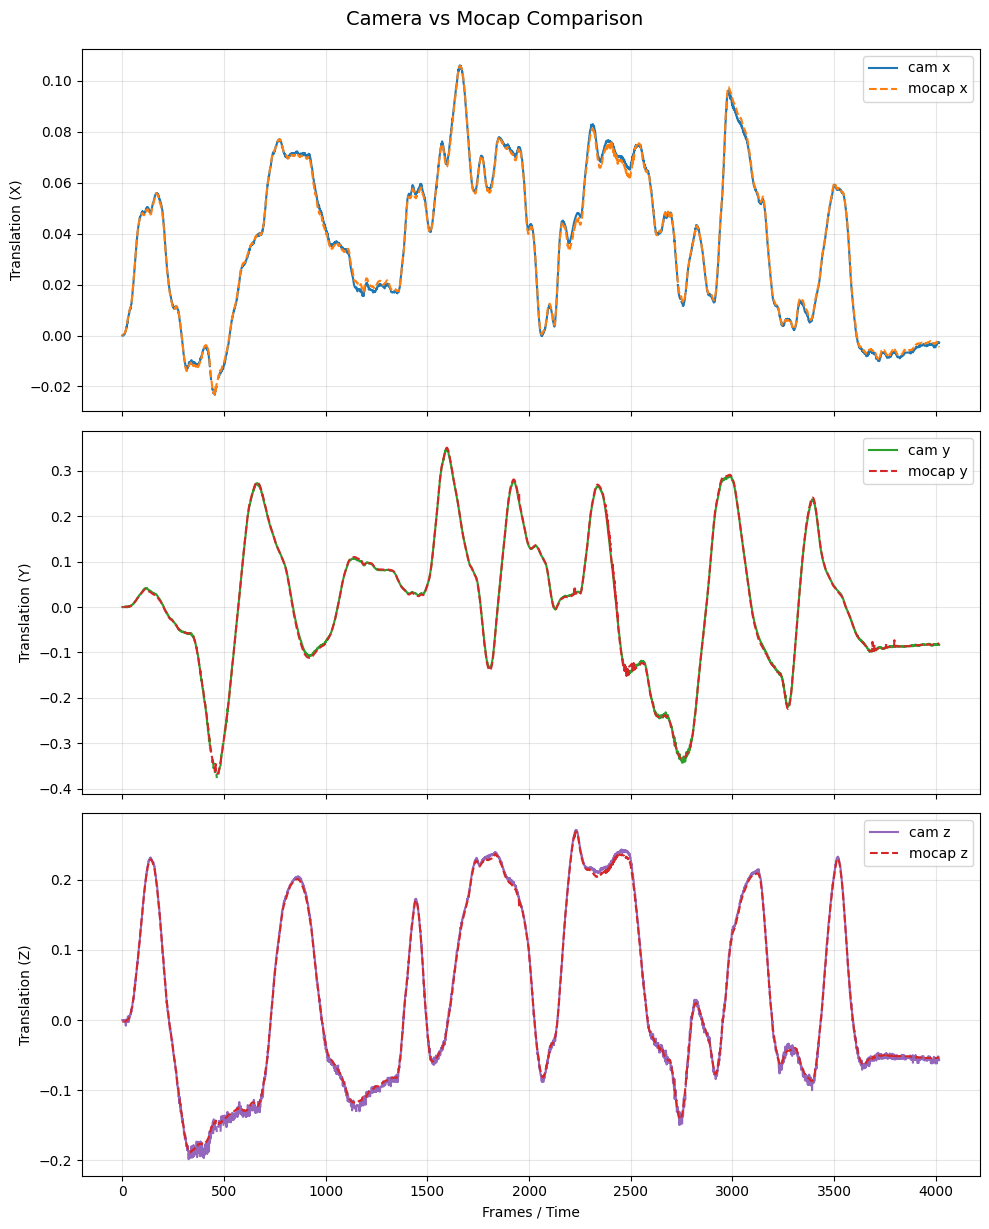

In [51]:
import matplotlib.pyplot as plt

# Create a figure with 3 subplots (rows), sharing the same x-axis
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Subplot for X
axes[0].plot(tvec_transformed[:, 1], label="cam x", color='tab:blue')
axes[0].plot(aligned_mocap[:,1], label="mocap x", color='tab:orange', linestyle='--')
axes[0].set_ylabel("Translation (X)")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)
# axes[0].set_ylim(-0.6, 0.6)


# Subplot for Y
axes[1].plot(tvec_transformed[:, 0], label="cam y", color='tab:green')
axes[1].plot(aligned_mocap[:,0], label="mocap y", color='tab:red', linestyle='--')
axes[1].set_ylabel("Translation (Y)")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)
# axes[1].set_ylim(-0.8, 0.8)

# Subplot for Z
axes[2].plot(tvec_transformed[:, 2], label="cam z", color='tab:purple')
axes[2].plot(aligned_mocap[:,2], label="mocap z", color='tab:red', linestyle='--')
# axes[2].plot(mocap_z, label="mocap z", color='tab:brown', linestyle='--')
axes[2].set_ylabel("Translation (Z)")
axes[2].set_xlabel("Frames / Time")
axes[2].legend(loc="upper right")
axes[2].grid(True, alpha=0.3)
# axes[2].set_ylim(-0.4, 0.4)

# Adjust layout to prevent label overlapping
plt.tight_layout()
plt.suptitle("Camera vs Mocap Comparison", y=1.02, fontsize=14)
plt.show()


In [36]:
# plt.plot(np.array(t_dict["z"]), label='AR X')
# plt.plot(mocap_ip["z"], label='Mocap X')
# plt.legend()

In [37]:
backup_dict = error_dict.copy()

In [38]:
np.min(error_dict['err_x'])

np.float64(0.35939281851924254)

In [39]:
STOP_HERE

NameError: name 'STOP_HERE' is not defined

In [ ]:
import toml

data = toml.load(r"E:\CMC\pyprojects\programs_rpi\NOARK_backbone\notebooks\calibration\output\template.toml")
data["calibration"]["camera_matrix"] = my_dict["mat"][min_index].tolist()
data["calibration"]["dist_coeffs"] = my_dict["dist"][min_index].tolist()
data["camera"]["resolution"] = (1280, 800)
with open(
    r"E:\CMC\pyprojects\programs_rpi\NOARK_backbone\notebooks\calibration\output\good.toml", "w"
) as f:
    toml.dump(data, f)

In [ ]:
min_index

np.int64(109)

## estimation

In [ ]:
# with open(os.path.join(_webcam_calib_video), "rb") as _f:
#     data = list(mp.Unpacker(_f, object_hook=mpn.decode))
# img_size = data[0]
# video_data = data[1:]

NameError: name '_webcam_calib_video' is not defined

## Check minimum graph

NameError: name 't_dict' is not defined

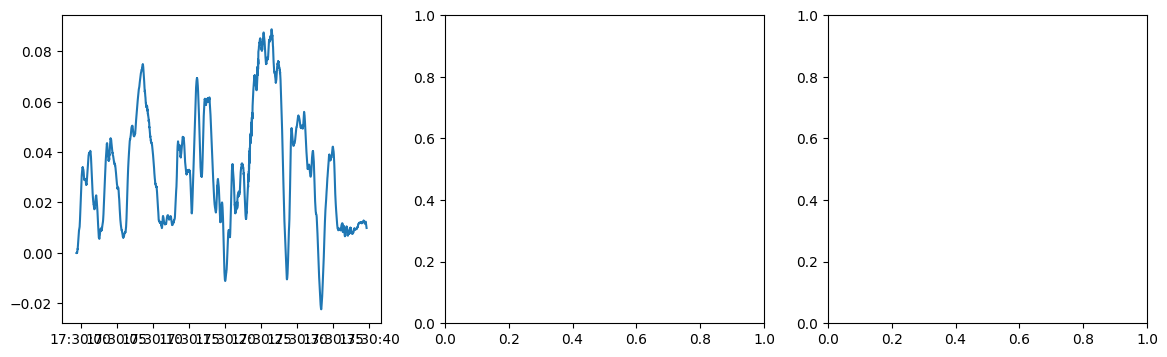

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(ar_df["time"], mocap_ip["x"], label="mocap x")
axes[0].plot(ar_df["time"], t_dict["x"], label="ar x")
axes[0].set_xlabel("time")
axes[0].set_ylabel("x in meters")
axes[0].legend()

axes[1].plot(ar_df["time"], mocap_ip["y"], label="mocap y")
axes[1].plot(ar_df["time"], t_dict["y"], label="aruco y")
axes[1].set_xlabel("time")
axes[1].set_ylabel("y in meters")
axes[1].legend()

axes[2].plot(ar_df["time"], mocap_ip["z"], label="mocap z")
axes[2].plot(ar_df["time"], np.array(t_dict["z"]), label="aruco z")
axes[2].set_xlabel("time")
axes[2].set_ylabel("z in meters")
axes[2].legend()
# axes[2].set_ylim([-0.01, 0.01])

plt.tight_layout()
plt.show()

In [ ]:
_cumulative_error = (
    np.array(error_dict["max_x"])
    + np.array(error_dict["max_y"])
    + np.array(error_dict["max_z"])
)
np.argmin(_cumulative_error)

2572

In [ ]:
mtx1 = error_dict["mtx"][index]
dist1 = error_dict["dist_coeffs"][index]

In [ ]:
error_dict["dist_coeffs"][index]

array([[-0.03554025, -0.31041969, -0.00555178, -0.00835112,  0.23764884]])

In [ ]:
import toml

data = toml.load(r"E:\CMC\pyprojects\programs_rpi\rpi_python\calib_test.toml")
data["calibration"]["camera_matrix"] = mtx1.tolist()
data["calibration"]["dist_coeffs"] = dist1.tolist()
data["camera"]["resolution"] = (1200, 480)
with open(
    r"E:\CMC\pyprojects\programs_rpi\rpi_python\calib_mono_faith3D.toml", "w"
) as f:
    toml.dump(data, f)

In [55]:
key = "mean_err"

index = np.argmin(error_dict[key])

index = 65
camera_matrix = error_dict["mtx"][index]
dist_coeffs = error_dict["dist_coeffs"][index]

rvecs = []
tvecs = []
for _c, _i in zip(corners, ids):
    if (_i is not None and len(_i) > 0) and all(
        item in default_ids for item in np.array(_i)
    ):
        rotation_vectors, translation_vectors = estimate_pose_single_markers(
            corners=_c,
            marker_size=0.05,
            camera_matrix=camera_matrix,
            distortion_coefficients=dist_coeffs,
        )
        rvecs.append(rotation_vectors[0][0])
        tvecs.append(translation_vectors[0][0])

    else:
        rvecs.append(np.array([np.nan, np.nan, np.nan]))
        tvecs.append(np.array([np.nan, np.nan, np.nan]))

tvecs = np.array(tvecs)
rvecs = np.array(rvecs)

t_dict = {"x": [], "y": [], "z": []}
rmat = cv2.Rodrigues(rvecs[1])[0]
ang_dict = {"rx": [], "ry": [], "rz": []}
for i in range(len(tvecs)):
    tvec = rmat.T @ (tvecs[i].reshape(3, 1) - tvecs[1].reshape(3, 1))
    tvec = tvec.T[0]
    t_dict["x"].append(tvec[0])
    t_dict["y"].append(tvec[1])
    t_dict["z"].append(tvec[2])
    _ang = R.from_matrix(rmat.T @ R.from_rotvec(rvecs[i]).as_matrix()).as_euler(
        "XYZ", degrees=True
    )
    ang_dict["rx"].append(_ang[0])
    ang_dict["ry"].append(_ang[1])
    ang_dict["rz"].append(_ang[2])

KeyError: 'mtx'

In [ ]:
index

2566

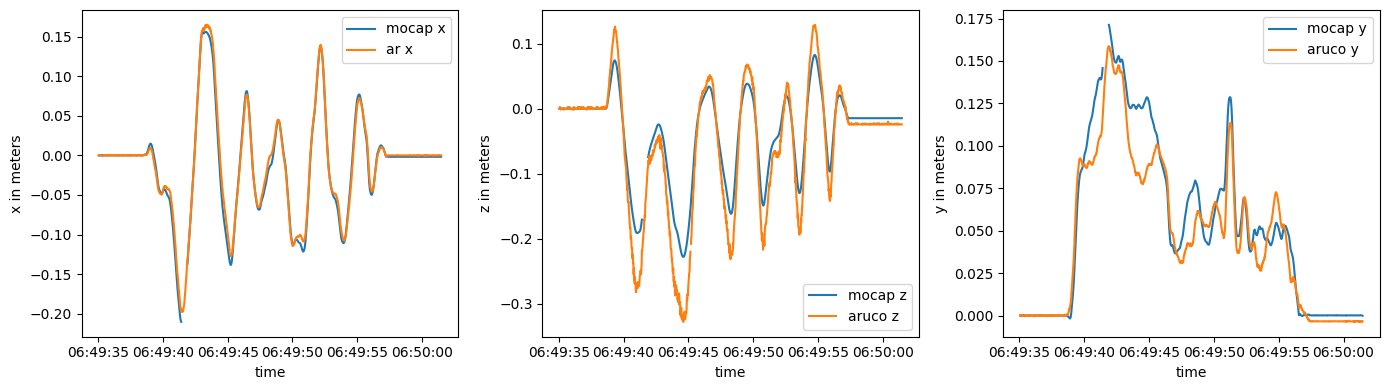

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(ar_df["time"], mocap_ip["x"], label="mocap x")
axes[0].plot(ar_df["time"], t_dict["x"], label="ar x")
axes[0].set_xlabel("time")
axes[0].set_ylabel("x in meters")
axes[0].legend()

axes[1].plot(ar_df["time"], mocap_ip["z"], label="mocap z")
axes[1].plot(ar_df["time"], np.array(t_dict["z"]), label="aruco z")
axes[1].set_xlabel("time")
axes[1].set_ylabel("z in meters")
axes[1].legend()

axes[2].plot(ar_df["time"], mocap_ip["y"], label="mocap y")
axes[2].plot(ar_df["time"], t_dict["y"], label="aruco y")
axes[2].set_xlabel("time")
axes[2].set_ylabel("y in meters")
axes[2].legend()
# axes[2].set_ylim([-0.01, 0.01])

plt.tight_layout()
plt.show()